In [9]:
# %%
# %%
CFG = {
    "RECORD_FILE_COL": "filename_lr",
    "LABEL_MODE": "5class",
    "SCP_MIN_CONF": 0.0,

    # Runtime
    "FAST_RUN": False,
    "MAX_RECORDS": None,
    "SEED": 42,

    # Disk/cache toggles — log-only (no files written)
    "USE_FEATURE_CACHE": False,
    "DEEP_CACHE_TO_DISK": True,
    "SAVE_MIN_TABLE": False,
    "SAVE_ARTIFACTS": False,

    "ART_DIR": "test/artifacts",
    "EDA_SKIP_HEAVY": True,

    # Memory & device knobs (PyTorch)
    "LOW_RAM": False,
    "TORCH_AMP": True,

    # Deep pipeline behavior
    "DEEP_FAST_METADATA_ONLY": True,

    # Train-time limiter
    "DEEP_MAX_TRAIN_FRAC": 0.80,

    # Models to run (PyTorch)
    "RUN_TORCH_CNN":  True,
    "RUN_TORCH_RNN":  True,
    "RUN_TORCH_LSTM": True,
    "RUN_TORCH_ANN":  True,
    "DEEP_HYBRID": False,

    # Sequence & training sizes
    "SEQ_LEN": 600,
    "DOWNSAMPLE_FACTOR": 2,
    "BATCH_SIZE": 24,
    "EPOCHS": 12,

    # === Exam requires MULTI-CLASS ===
    "BINARY_TASK": False,               # keep OFF for 5-class
    "BINARY_SCHEME": "NORM_vs_ALL",

    # Cross-validation
    "RUN_KFOLD_ALL": True,
    "KFOLDS": 5,
    "CV_EPOCHS": 5,

    # Training quality knobs
    "EARLY_STOP_PATIENCE": 3,
    "EARLY_STOP_MONITOR": "acc",
    "GRAD_CLIP_NORM": 1.0,
    "BASE_LR": 3e-4,        # for CNN
    "RECURRENT_LR": 2e-4,   # for RNN/LSTM/ANN

    # Confusion-matrix preference
    "CONFUSION_COLLAPSE_TO_3": False,

    # ===== NEW: Baseline & feature engineering =====
    "RUN_BASELINE_DUMMY": True,        # simple majority/stratified baseline
    "RUN_FEATURES_BUILD": True,        # build signal-stats features
    "SAVE_FEATURES_CSV": True,         # save features to CSV
    "FEATURES_CSV_NAME": "basic_signal_features.csv",
    "FEATURES_USE_FOR_BASELINE": True, # use engineered features for baseline

    # --- Federated Learning (exam: 3–4 clients) ---
    "FL_BASE_MODEL": "ANN",
    "FL_N_CLIENTS": 4,
    "FL_SAMPLE_FRAC": 0.75,
    "FL_LOCAL_EPOCHS": 1,
    "FL_ROUNDS": 10,
    "FL_PARTITION": "by_patient",
    "FL_DIRICHLET_ALPHA": 0.3,
    "FL_MIN_SAMPLES_PER_CLIENT": 25,
    "FL_BALANCE_BY_SIZE": True,
}

# Keep these AFTER the update
if CFG["FAST_RUN"] and (CFG["MAX_RECORDS"] is None):
    CFG["MAX_RECORDS"] = 200
if CFG["FAST_RUN"]:
    CFG["EPOCHS"] = min(CFG["EPOCHS"], 4)

print(CFG)


{'RECORD_FILE_COL': 'filename_lr', 'LABEL_MODE': '5class', 'SCP_MIN_CONF': 0.0, 'FAST_RUN': False, 'MAX_RECORDS': None, 'SEED': 42, 'USE_FEATURE_CACHE': False, 'DEEP_CACHE_TO_DISK': True, 'SAVE_MIN_TABLE': False, 'SAVE_ARTIFACTS': False, 'ART_DIR': 'test/artifacts', 'EDA_SKIP_HEAVY': True, 'LOW_RAM': False, 'TORCH_AMP': True, 'DEEP_FAST_METADATA_ONLY': True, 'DEEP_MAX_TRAIN_FRAC': 0.8, 'RUN_TORCH_CNN': True, 'RUN_TORCH_RNN': True, 'RUN_TORCH_LSTM': True, 'RUN_TORCH_ANN': True, 'DEEP_HYBRID': False, 'SEQ_LEN': 600, 'DOWNSAMPLE_FACTOR': 2, 'BATCH_SIZE': 24, 'EPOCHS': 12, 'BINARY_TASK': False, 'BINARY_SCHEME': 'NORM_vs_ALL', 'RUN_KFOLD_ALL': True, 'KFOLDS': 5, 'CV_EPOCHS': 5, 'EARLY_STOP_PATIENCE': 3, 'EARLY_STOP_MONITOR': 'acc', 'GRAD_CLIP_NORM': 1.0, 'BASE_LR': 0.0003, 'RECURRENT_LR': 0.0002, 'CONFUSION_COLLAPSE_TO_3': False, 'RUN_BASELINE_DUMMY': True, 'RUN_FEATURES_BUILD': True, 'SAVE_FEATURES_CSV': True, 'FEATURES_CSV_NAME': 'basic_signal_features.csv', 'FEATURES_USE_FOR_BASELINE': T

In [10]:
# %% [markdown]
# ## 1) Setup & Reproducibility

# %%
import os, random, time, json, warnings, ast, sys, subprocess
import numpy as np, pandas as pd
from IPython.display import display, Markdown
warnings.filterwarnings("ignore")

SEED = CFG["SEED"]
random.seed(SEED); np.random.seed(SEED)

def ts(): return time.strftime("%Y-%m-%d %H:%M:%S")
def log(msg): print(f"[{ts()}] {msg}")

try:
    from importlib.metadata import version
    log(f"Versions — pandas {version('pandas')}, numpy {version('numpy')}")
except Exception:
    pass

log("Seeds set.")

[2025-10-11 12:18:16] Versions — pandas 2.3.2, numpy 1.26.4
[2025-10-11 12:18:16] Seeds set.


In [11]:
# %% [markdown]
# ## 2) Paths & Sanity Checks

# %%
from pathlib import Path

DB_CSV  = "dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/ptbxl_database.csv"
SCP_CSV = "dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/scp_statements.csv"

ROOT = Path(DB_CSV).parent
RECORDS_DIR = ROOT / ("records100" if CFG["RECORD_FILE_COL"] == "filename_lr" else "records500")

assert Path(DB_CSV).exists(),  f"Missing {DB_CSV}"
assert Path(SCP_CSV).exists(), f"Missing {SCP_CSV}"
assert RECORDS_DIR.exists(),   f"Missing {RECORDS_DIR}"

# Quick WFDB read
try:
    import wfdb
    sig0, meta0 = wfdb.rdsamp(str(RECORDS_DIR / "00000" / "00001_lr"))
    log(f"WFDB OK: shape={sig0.shape}, leads={meta0.get('sig_name', [])[:4]}...")
except ImportError as e:
    raise RuntimeError("Please install WFDB →  %pip install wfdb") from e
except Exception as e:
    log(f"WFDB sample read failed (not fatal): {e}")

[2025-10-11 12:18:16] WFDB OK: shape=(1000, 12), leads=['I', 'II', 'III', 'AVR']...


In [12]:
# %% [markdown]
# ## 3) Load CSVs

# %%
db  = pd.read_csv(DB_CSV)
scp_raw = pd.read_csv(SCP_CSV, encoding="utf-8-sig")
scp_raw.columns = [str(c).strip() for c in scp_raw.columns]
log(f"Loaded db: {db.shape} | scp: {scp_raw.shape}")
display(db.head(3)); display(scp_raw.head(3))

[2025-10-11 12:18:16] Loaded db: (21799, 28) | scp: (71, 13)


,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
0,1,15709,56,1,NaN,63.0,2.0,0.0,CS-12 E,11/9/84 9:17,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
1,2,13243,19,0,NaN,70.0,2.0,0.0,CS-12 E,11/14/84 12:55,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
2,3,20372,37,1,NaN,69.0,2.0,0.0,CS-12 E,11/15/84 12:49,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr


,Unnamed: 0,description,diagnostic,form,rhythm,diagnostic_class,diagnostic_subclass,Statement Category,SCP-ECG Statement Description,AHA code,aECG REFID,CDISC Code,DICOM Code
0,NDT,non-diagnostic T abnormalities,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,non-diagnostic T abnormalities,NaN,NaN,NaN,NaN
1,NST_,non-specific ST changes,1.0,1.0,NaN,STTC,NST_,Basic roots for coding ST-T changes and abnorm...,non-specific ST changes,145.0,MDC_ECG_RHY_STHILOST,NaN,NaN
2,DIG,digitalis-effect,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,suggests digitalis-effect,205.0,NaN,NaN,NaN


In [13]:
# %% [markdown]
# ## 4) Target Mapping (SCP → 5-class or 10-class)

# %%
def _extract_scp_keys(db_series, n=2000):
    keys = set()
    for s in db_series.head(min(n, len(db_series))):
        try: keys.update(map(str, ast.literal_eval(s).keys()))
        except Exception: pass
    return keys

known_keys = _extract_scp_keys(db["scp_codes"], n=2000)
obj_cols = [c for c in scp_raw.columns if scp_raw[c].dtype == "object"]
scores = {c: len(set(scp_raw[c].astype(str)).intersection(known_keys)) for c in obj_cols} or {obj_cols[0]:1}
code_col = max(scores, key=scores.get)

scp_raw["code"] = scp_raw[code_col].astype(str)
scp = scp_raw.set_index("code", drop=False); scp.index.name = "code"

for req in ["diagnostic", "diagnostic_class", "diagnostic_subclass"]:
    if req not in scp.columns:
        raise ValueError(f"scp_statements.csv missing column: {req}")

diag_col = scp["diagnostic"].astype(str).str.strip().str.lower()
diag_mask = pd.to_numeric(diag_col, errors="coerce").fillna(0).gt(0) | diag_col.isin({"1","1.0","true","t","yes","y","on"})
diag_only = scp.loc[diag_mask, ["diagnostic_class","diagnostic_subclass"]].copy()
valid_codes = set(diag_only.index)

label_field = "diagnostic_class" if CFG["LABEL_MODE"] == "5class" else "diagnostic_subclass"

def to_diag_label(scp_codes_dict, min_conf=0.0):
    try:
        items = [(str(k), float(v)) for k, v in scp_codes_dict.items()]
    except Exception:
        return None
    items = [(k, v) for k, v in items if k in valid_codes and v >= min_conf]
    if not items: return None
    agg = {}
    for k, w in items:
        agg[diag_only.loc[k, label_field]] = agg.get(diag_only.loc[k, label_field], 0.0) + w
    return max(agg.items(), key=lambda kv: kv[1])[0]

In [14]:
# %% [markdown]
# ## 5) Minimal table for deep (log-only unless SAVE_MIN_TABLE=True)

# %%
from joblib import Parallel, delayed
from typing import Dict, Any

OUT_CSV = ROOT / "ptbxl_minimal_for_deep.csv"
META_FIELDS = ["ecg_id","patient_id","age","sex","device","recording_date","scp_codes","strat_fold"]

def _one_row_min(r: dict) -> dict | None:
    row: Dict[str, Any] = {}
    for k in META_FIELDS:
        v = r.get(k, np.nan)
        if k == "recording_date":
            try: row[k] = pd.to_datetime(v).date().isoformat()
            except Exception: row[k] = np.nan
        else:
            row[k] = v
    try:
        scp_codes = ast.literal_eval(r.get("scp_codes", "{}"))
    except Exception:
        return None
    y = to_diag_label(scp_codes, CFG["SCP_MIN_CONF"])
    if y is None: return None

    rec_dat = ROOT / r[CFG["RECORD_FILE_COL"]]
    rec_noext = str(rec_dat)[:-4] if str(rec_dat).endswith(".dat") else str(rec_dat)
    row["record_path"] = rec_noext
    row["label"] = y
    return row

def build_minimal_table(db: pd.DataFrame, max_records=None) -> pd.DataFrame:
    rows = db.to_dict(orient="records")
    if max_records: rows = rows[:max_records]
    res = Parallel(n_jobs=-1, prefer="threads")(delayed(_one_row_min)(r) for r in rows)
    res = [r for r in res if r is not None]
    if not res: raise RuntimeError("No rows produced — check file paths/mappings.")
    df = pd.DataFrame(res)
    log(f"Minimal deep table: n={len(df)}")
    return df

if OUT_CSV.exists() and CFG["USE_FEATURE_CACHE"] and CFG["DEEP_FAST_METADATA_ONLY"]:
    features_df = pd.read_csv(OUT_CSV)
    log(f"Using cached minimal table: {OUT_CSV} {features_df.shape}")
else:
    features_df = build_minimal_table(db, CFG["MAX_RECORDS"])
    if CFG["SAVE_MIN_TABLE"] and CFG["DEEP_FAST_METADATA_ONLY"]:
        OUT_CSV.parent.mkdir(parents=True, exist_ok=True)
        features_df.to_csv(OUT_CSV, index=False)
        log(f"Saved → {OUT_CSV}")
    else:
        log("Minimal table generated (not saved).")

print("Shape:", features_df.shape)
display(features_df.head(10))
print("\nClass counts:")
display(features_df["label"].value_counts().rename_axis("label").to_frame("count"))

[2025-10-11 12:18:20] Minimal deep table: n=21388
[2025-10-11 12:18:20] Minimal table generated (not saved).
Shape: (21388, 10)


,ecg_id,patient_id,age,sex,device,recording_date,scp_codes,strat_fold,record_path,label
0,1,15709,56,1,CS-12 E,1984-11-09,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}",3,dataset/ptb-xl-a-large-publicly-available-elec...,NORM
1,2,13243,19,0,CS-12 E,1984-11-14,"{'NORM': 80.0, 'SBRAD': 0.0}",2,dataset/ptb-xl-a-large-publicly-available-elec...,NORM
2,3,20372,37,1,CS-12 E,1984-11-15,"{'NORM': 100.0, 'SR': 0.0}",5,dataset/ptb-xl-a-large-publicly-available-elec...,NORM
3,4,17014,24,0,CS-12 E,1984-11-15,"{'NORM': 100.0, 'SR': 0.0}",3,dataset/ptb-xl-a-large-publicly-available-elec...,NORM
4,5,17448,19,1,CS-12 E,1984-11-17,"{'NORM': 100.0, 'SR': 0.0}",4,dataset/ptb-xl-a-large-publicly-available-elec...,NORM
5,6,19005,18,1,CS-12 E,1984-11-28,"{'NORM': 100.0, 'SR': 0.0}",4,dataset/ptb-xl-a-large-publicly-available-elec...,NORM
6,7,16193,54,0,CS-12 E,1984-11-28,"{'NORM': 100.0, 'SR': 0.0}",7,dataset/ptb-xl-a-large-publicly-available-elec...,NORM
7,8,11275,48,0,CS-12 E,1984-12-01,"{'IMI': 35.0, 'ABQRS': 0.0, 'SR': 0.0}",9,dataset/ptb-xl-a-large-publicly-available-elec...,MI
8,9,18792,55,0,CS-12 E,1984-12-08,"{'NORM': 100.0, 'SR': 0.0}",10,dataset/ptb-xl-a-large-publicly-available-elec...,NORM
9,10,9456,22,1,CS-12 E,1984-12-12,"{'NORM': 100.0, 'SR': 0.0}",9,dataset/ptb-xl-a-large-publicly-available-elec...,NORM



Class counts:


,count
label,
NORM,9243
MI,4049
CD,3431
STTC,3360
HYP,1305


In [15]:
# %%
# 5b) Feature Engineering — per-lead stats + coarse bandpower (robust, order-agnostic)

import numpy as np, pandas as pd
from pathlib import Path

# --- prerequisites from §5
assert "features_df" in globals(), "Run §5 to build 'features_df' first."
df_local = features_df.copy()
assert "record_path" in df_local.columns and "label" in df_local.columns, \
    "'features_df' must contain 'record_path' and 'label'."

# --- config helpers
def _sr_from_cfg():
    return 100 if CFG.get("RECORD_FILE_COL", "filename_lr") == "filename_lr" else 500

# --- ECG loader: use existing if available; else provide a minimal local version
try:
    _ = _load_ecg_numpy  # probe
    def _load_ecg_np(path: str):
        return _load_ecg_numpy(path)
except NameError:
    import wfdb
    STD_LEADS = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]
    def _load_ecg_np(rec_path: str):
        x, meta = wfdb.rdsamp(rec_path)   # (samples, channels)
        x = x.astype("float32")
        # Try to select standard 12 leads if present (order-robust)
        try:
            sig_names = meta.get("sig_name", [])
            if len(sig_names) >= 12 and all(s in sig_names for s in STD_LEADS):
                idx = [sig_names.index(s) for s in STD_LEADS]
                x = x[:, idx]
        except Exception:
            pass
        # Downsample + trim/pad to target length derived from CFG
        factor = int(CFG.get("DOWNSAMPLE_FACTOR", 2))
        T_eff  = max(1, int(CFG.get("SEQ_LEN", 600)) // max(1, factor))
        if factor > 1:
            x = x[::factor]
        if x.shape[0] >= T_eff:
            x = x[:T_eff, :]
        else:
            pad = np.zeros((T_eff - x.shape[0], x.shape[1]), dtype="float32")
            x = np.vstack([x, pad])
        return x  # (T, C)

# --- bandpower + per-lead statistics
def _bandpower(sig_1d, fs, f_lo, f_hi):
    x = sig_1d.astype(np.float32)
    n = len(x)
    if n == 0: return 0.0
    freqs = np.fft.rfftfreq(n, d=1.0/fs)
    spec  = np.abs(np.fft.rfft(x))**2
    mask  = (freqs >= f_lo) & (freqs < f_hi)
    msum  = int(mask.sum())
    return float(spec[mask].sum() / max(1, msum))

def _features_for_record(path, fs, leads=12):
    X = _load_ecg_np(path)          # (T, C)
    feats = {}
    # time-domain stats per lead
    for j in range(min(leads, X.shape[1])):
        s = X[:, j]
        feats[f"L{j+1}_mean"] = float(np.mean(s))
        feats[f"L{j+1}_std"]  = float(np.std(s))
        feats[f"L{j+1}_rms"]  = float(np.sqrt(np.mean(s*s)))
        feats[f"L{j+1}_ptp"]  = float(np.ptp(s))
    # coarse bandpower per lead (ECG-ish bands)
    bands = [(0.0,5.0),(5.0,15.0),(15.0,40.0)]
    for j in range(min(leads, X.shape[1])):
        s = X[:, j]
        for (a,b) in bands:
            feats[f"L{j+1}_bp_{int(a)}_{int(b)}Hz"] = _bandpower(s, fs, a, b)
    return feats

# --- build features for ALL rows present in features_df (no dependency on §8)
if CFG.get("RUN_FEATURES_BUILD", True):
    fs = _sr_from_cfg()
    idx_iter = df_local.index
    paths    = df_local["record_path"].astype(str)

    rows = []
    for k, idx in enumerate(idx_iter, start=1):
        p = paths.loc[idx]
        try:
            rows.append({"index": int(idx), **_features_for_record(p, fs)})
        except Exception:
            # skip unreadable records but keep going
            continue
        if (k % 200) == 0:
            print(f"[Features] {k}/{len(idx_iter)} done...")

    feature_df = pd.DataFrame(rows).set_index("index").sort_index()

    # attach labels directly from features_df (order-agnostic)
    feature_df["label"] = df_local.loc[feature_df.index, "label"].astype(str)

    print("[Features] shape:", feature_df.shape)
    display(feature_df.head(3))

    if CFG.get("SAVE_FEATURES_CSV", True):
        out = Path(CFG.get("ART_DIR", "artifacts")) / CFG.get("FEATURES_CSV_NAME", "basic_signal_features.csv")
        out.parent.mkdir(parents=True, exist_ok=True)
        feature_df.to_csv(out)
        print("Saved:", out)
else:
    print("[Features] Skipped (RUN_FEATURES_BUILD=False)")


[Features] 200/21388 done...
[Features] 400/21388 done...
[Features] 600/21388 done...
[Features] 800/21388 done...
[Features] 1000/21388 done...
[Features] 1200/21388 done...
[Features] 1400/21388 done...
[Features] 1600/21388 done...
[Features] 1800/21388 done...
[Features] 2000/21388 done...
[Features] 2200/21388 done...
[Features] 2400/21388 done...
[Features] 2600/21388 done...
[Features] 2800/21388 done...
[Features] 3000/21388 done...
[Features] 3200/21388 done...
[Features] 3400/21388 done...
[Features] 3600/21388 done...
[Features] 3800/21388 done...
[Features] 4000/21388 done...
[Features] 4200/21388 done...
[Features] 4400/21388 done...
[Features] 4600/21388 done...
[Features] 4800/21388 done...
[Features] 5000/21388 done...
[Features] 5200/21388 done...
[Features] 5400/21388 done...
[Features] 5600/21388 done...
[Features] 5800/21388 done...
[Features] 6000/21388 done...
[Features] 6200/21388 done...
[Features] 6400/21388 done...
[Features] 6600/21388 done...
[Features] 680

,L1_mean,L1_std,L1_rms,L1_ptp,L2_mean,L2_std,L2_rms,L2_ptp,L3_mean,L3_std,...,L10_bp_0_5Hz,L10_bp_5_15Hz,L10_bp_15_40Hz,L11_bp_0_5Hz,L11_bp_5_15Hz,L11_bp_15_40Hz,L12_bp_0_5Hz,L12_bp_5_15Hz,L12_bp_15_40Hz,label
index,,,,,,,,,,,,,,,,,,,,,
0,-0.021097,0.110960,0.112948,0.818,0.004363,0.084247,0.084360,0.563,0.025497,0.052474,...,4.135040,2.582257,2.784803,3.316127,4.193363,2.079194,9.538911,4.724564,1.664405,NORM
1,0.004147,0.133264,0.133329,1.013,0.049400,0.238990,0.244042,1.868,0.045277,0.177118,...,48.560014,20.891781,14.778418,30.082737,17.025715,10.177883,24.517625,12.163715,6.136823,NORM
2,-0.010210,0.125054,0.125470,0.928,-0.024093,0.137989,0.140077,0.959,-0.013890,0.117659,...,10.671212,7.074423,5.944294,9.293729,4.968704,3.308262,12.895468,4.192779,2.142050,NORM


Saved: test/artifacts/basic_signal_features.csv


Top missingness by column:


,NA_rate
ecg_id,0.0
patient_id,0.0
age,0.0
sex,0.0
device,0.0
recording_date,0.0
scp_codes,0.0
strat_fold,0.0
record_path,0.0
label,0.0


No missing values detected — skipping missingness plot.


,count,pct
label,,
NORM,9243,43.22
MI,4049,18.93
CD,3431,16.04
STTC,3360,15.71
HYP,1305,6.10


Saved: test/artifacts/figs/eda_class_counts.png


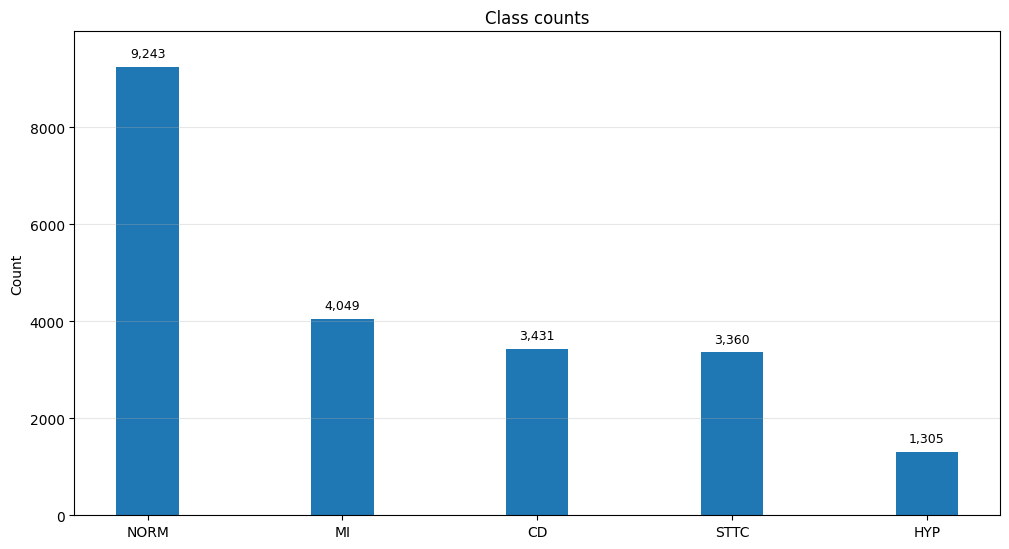

Saved: test/artifacts/figs/eda_sex_overall.png


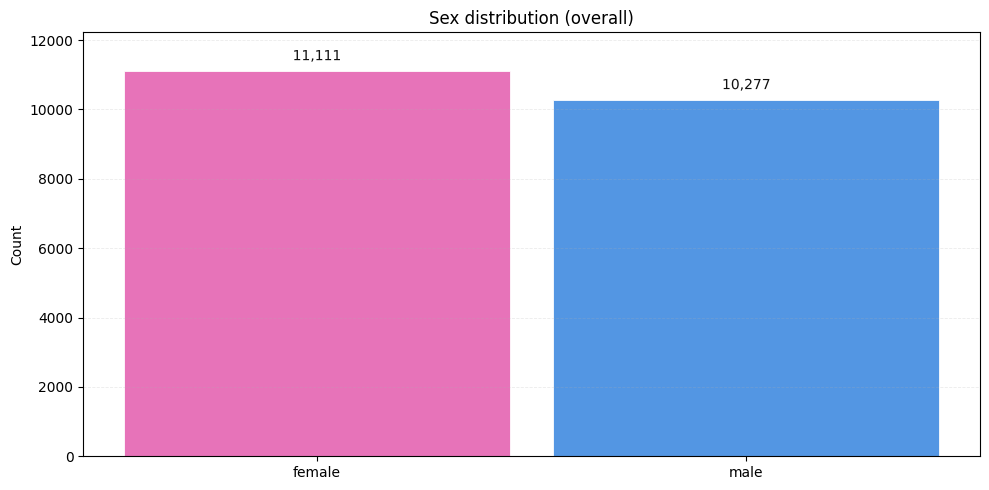

Saved: test/artifacts/figs/eda_class_by_sex_counts.png


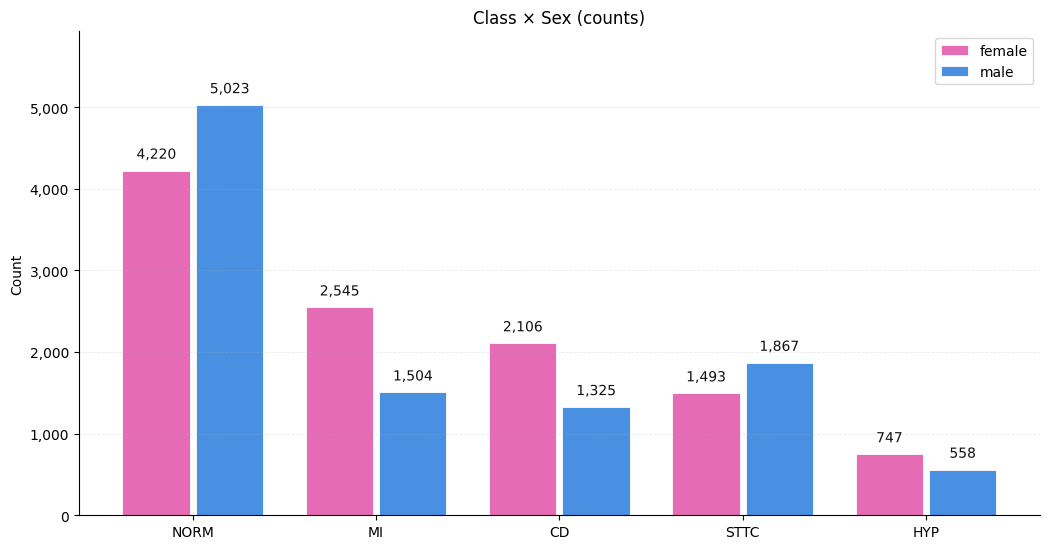

Saved: test/artifacts/figs/eda_class_by_sex_percent.png


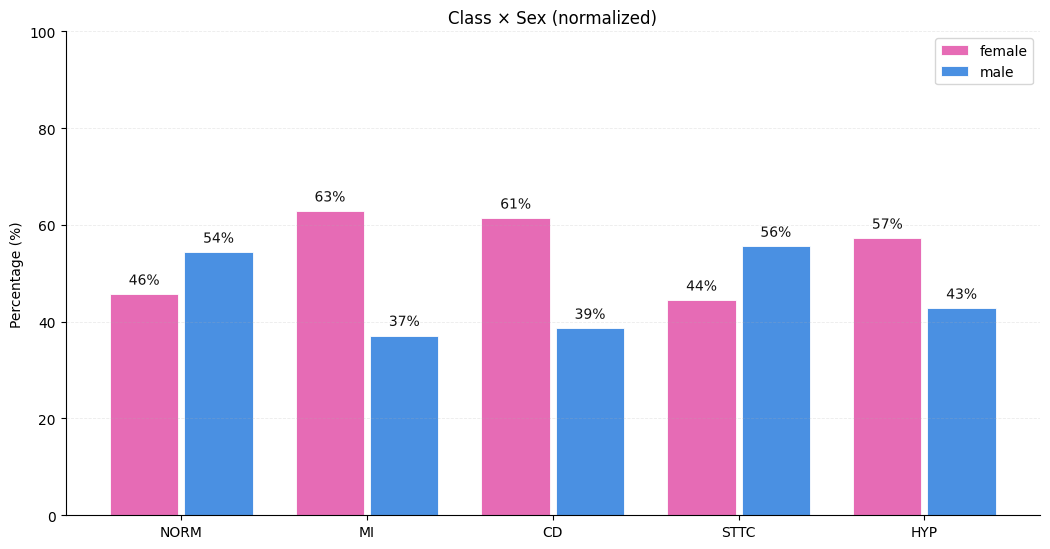

Saved: test/artifacts/figs/eda_age_hist_overall_pretty.png


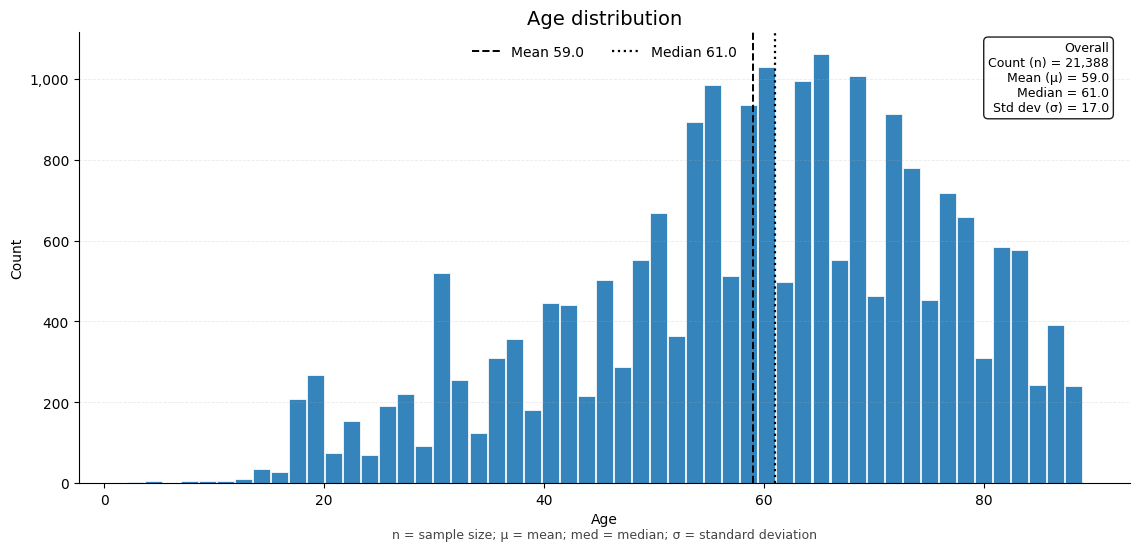

Saved: test/artifacts/figs/eda_age_by_class_box_pretty.png


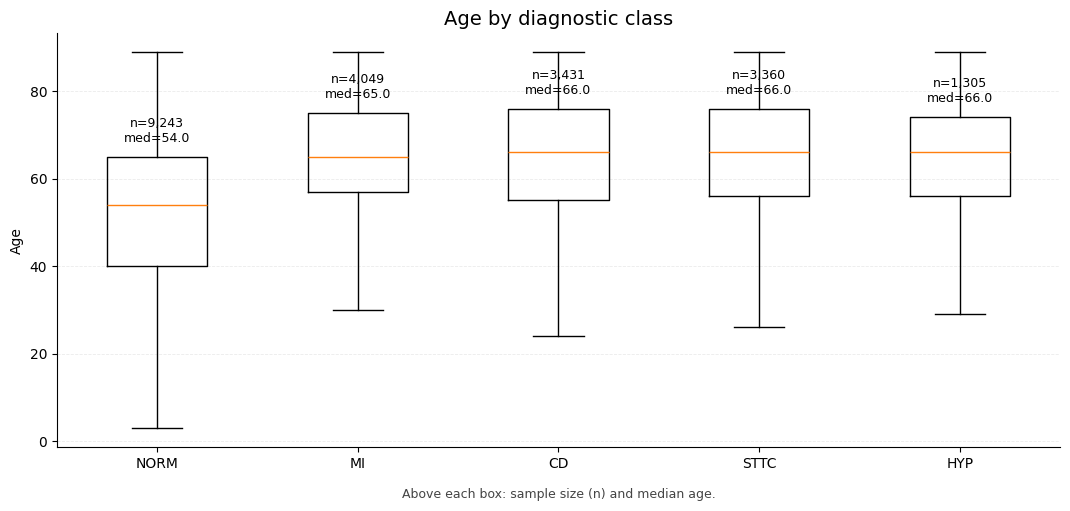

Saved: test/artifacts/figs/eda_age_hist_by_sex_overlay_pretty.png


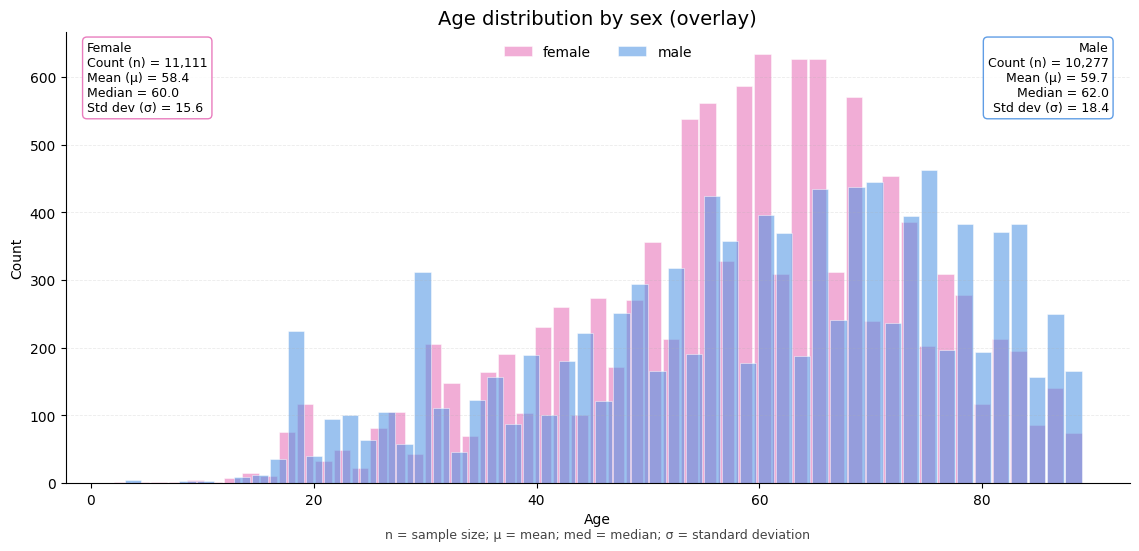

Saved: test/artifacts/figs/eda_age_by_sex_box_pretty.png


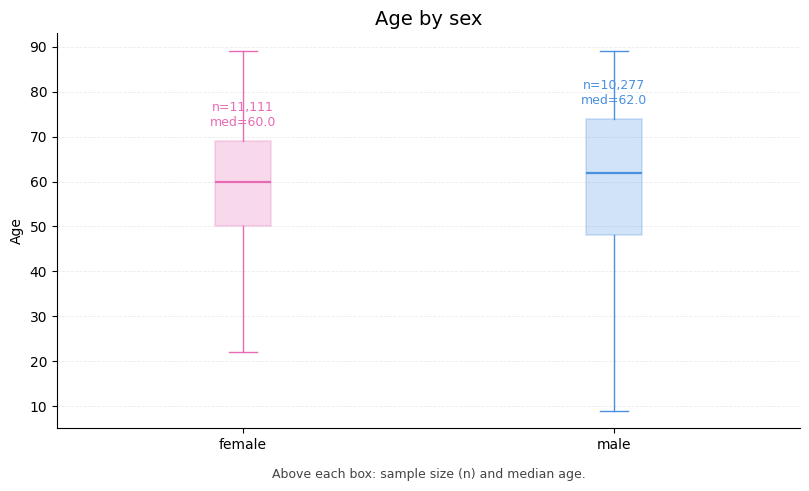

Saved: test/artifacts/figs/eda_records_per_year_pretty_alllabels.png


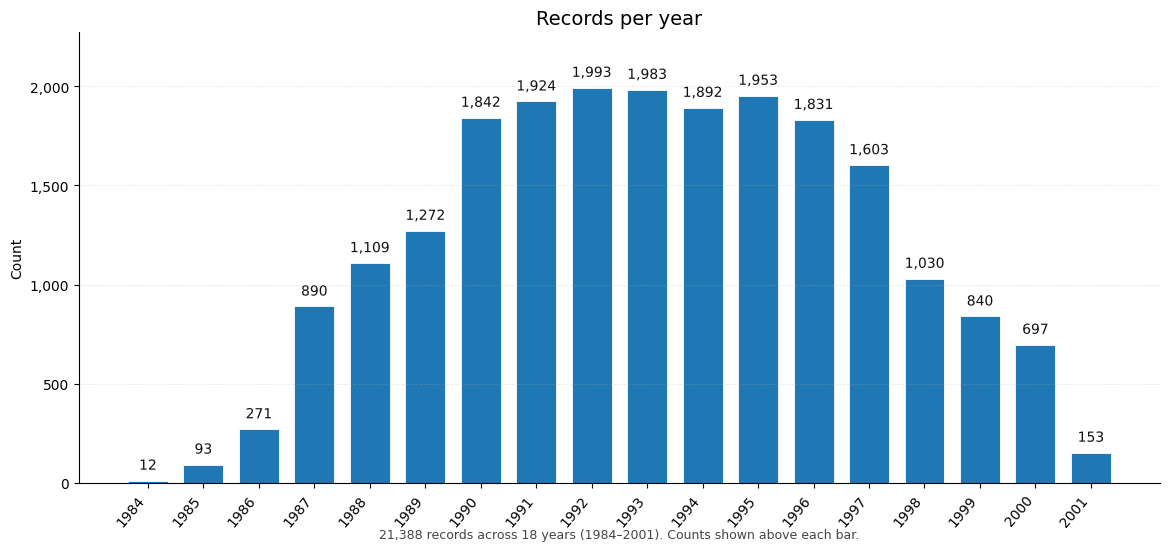

Saved: test/artifacts/figs/eda_fold_class_counts_grouped_pretty.png


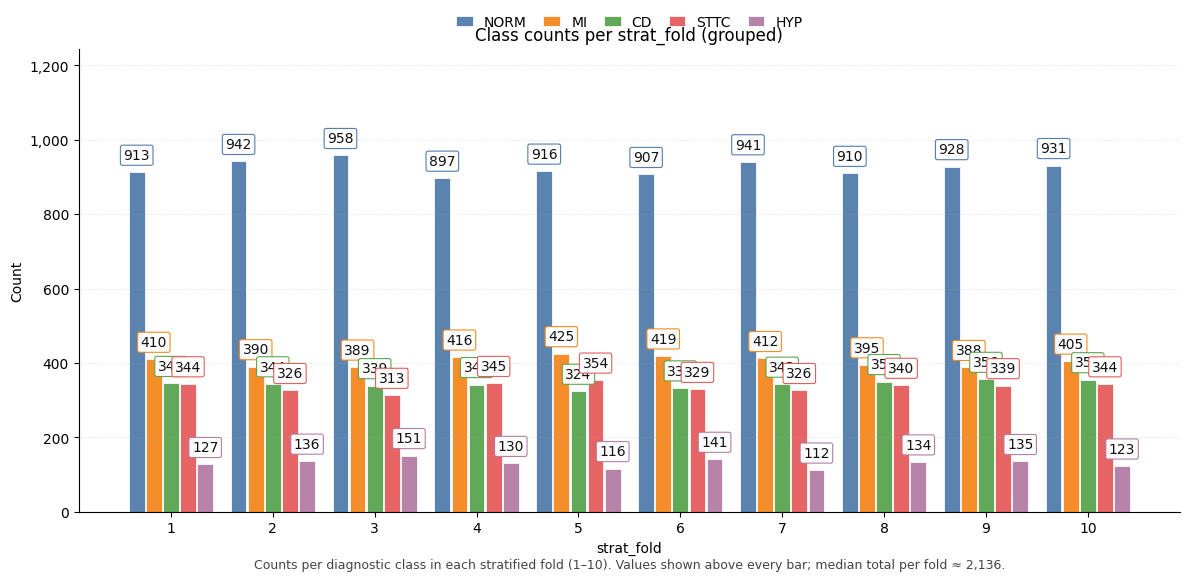

In [16]:
# %% [markdown]
# # 6) EDA — Expanded (clean styling, labels, spacing, prettier visuals)

# %%
import numpy as np, pandas as pd, matplotlib.pyplot as plt, textwrap
from pathlib import Path
from IPython.display import display
from matplotlib.ticker import FuncFormatter
from matplotlib import patheffects as pe  # for readable outlined text

# ========= Output directory =========
ART_DIR = Path(CFG.get("ART_DIR", "artifacts")) / "figs"
ART_DIR.mkdir(parents=True, exist_ok=True)

# ========= Central knobs (can be overridden in CFG) =========
BAR_BASE    = float(CFG.get("EDA_BAR_WIDTH", 0.32))   # ~0.28–0.38 looks nice
SPREAD_BASE = float(CFG.get("EDA_BAR_SPREAD", 1.00))  # 1.00 = standard spacing

# Add small gaps between grouped bars & histogram bins
GAP_FRAC_GROUPED = float(CFG.get("EDA_GROUPED_GAP", 0.08))   # 0.05–0.12 looks good

# ========= Palettes =========
SEX_COLORS = {"female": "#E66BB5", "male": "#4A90E2", "unknown": "#9B9B9B"}
CLASS_COLORS = {"NORM": "#4C78A8", "MI": "#F58518", "CD": "#54A24B", "STTC": "#E45756", "HYP": "#B279A2"}

# ========= Small utilities =========
def _save(fig, name):
    out = ART_DIR / name
    fig.savefig(out, dpi=300, bbox_inches="tight")
    print("Saved:", out)

def _wrap(names, width=12):
    return ["\n".join(textwrap.wrap(str(n), width=width)) for n in names]

def _bar_width(n, base=BAR_BASE):
    return float(np.clip(base, 0.18, 0.45))

def _x_positions(n, spread=SPREAD_BASE):
    return np.arange(n) * spread

def _add_counts(ax, xs, ys, dy_frac=0.015):
    if len(ys) == 0: return
    ymax = float(np.nanmax(ys)) if len(ys) else 1.0
    for x, y in zip(xs, ys):
        ax.text(x, y + max(1, dy_frac * ymax), f"{int(y):,}",
                ha="center", va="bottom", fontsize=9)

def _barplot(categories, values, title, ylabel="",
             fname="plot.png", figsize=(9.8, 5.2), annotate=True,
             spread=SPREAD_BASE, width=None, color_map=None,
             ylim_pad_frac=0.08, annotate_offset_frac=0.015):
    """Vertical bar plot with headroom control so bars look taller."""
    n  = len(categories)
    xs = _x_positions(n, spread)
    w  = _bar_width(n, BAR_BASE if width is None else width)
    fig, ax = plt.subplots(figsize=figsize)
    colors = [color_map.get(c, None) for c in categories] if color_map else None
    ax.bar(xs, values, width=w, color=colors)
    ymax = float(np.nanmax(values)) if len(values) else 1.0
    ax.set_ylim(0, ymax * (1.0 + float(ylim_pad_frac)))
    ax.set_xticks(xs); ax.set_xticklabels(categories)
    ax.set_title(title)
    if ylabel: ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.3)
    if annotate: _add_counts(ax, xs, values, dy_frac=float(annotate_offset_frac))
    plt.tight_layout(); _save(fig, fname); plt.show()

def _add_counts_grouped(ax, x_centers, matrix, group_width=0.80, bar_w=None,
                        dy_frac=0.015, fmt="{:,.0f}"):
    """Annotate values for grouped bars."""
    m = np.asarray(matrix, dtype=float)
    if m.size == 0: return
    _, K = m.shape
    if K == 0: return
    if bar_w is None: bar_w = group_width / K
    ymax = max(np.nanmax(m), 1.0)
    for j in range(K):
        offs = -group_width/2 + j*bar_w + bar_w/2
        ys = m[:, j]
        for xi, y in zip(x_centers + offs, ys):
            if np.isnan(y): continue
            ax.text(xi, y + max(1, dy_frac * ymax), fmt.format(y),
                    ha="center", va="bottom", fontsize=9)

# ========= Outlined text helpers (good over colored bars) =========
def _text_with_outline(ax, x, y, s, fontsize=10, color="#111",
                       outline_width=2.0, outline_color="white", **kwargs):
    t = ax.text(x, y, s, ha="center", va="bottom",
                fontsize=fontsize, color=color, **kwargs)
    t.set_path_effects([pe.Stroke(linewidth=outline_width, foreground=outline_color),
                        pe.Normal()])
    return t

def _label_bars_grouped_readable(ax, x_centers, matrix,
                                 group_width, bar_w,
                                 dy_frac=0.02, fmt="{:,.0f}", fontsize=10):
    m = np.asarray(matrix, float)
    if m.size == 0: return
    ymax = float(np.nanmax(m)) if m.size else 1.0
    dy = max(1.0, dy_frac * ymax)
    G, K = m.shape
    for j in range(K):
        offs = -group_width/2 + j*bar_w + bar_w/2
        for xi, y in zip(x_centers + offs, m[:, j]):
            _text_with_outline(ax, xi, y + dy, fmt.format(y), fontsize=fontsize)

# ========= Boxed label helper (highest contrast) =========
def _label_bars_grouped_boxed(ax, x_centers, matrix,
                              group_width, bar_w,
                              dy_frac=0.03, fontsize=10, edge_colors=None):
    """
    Label EVERY grouped bar with a small white rounded box so it's readable
    against any bar color.
    """
    m = np.asarray(matrix, float)
    if m.size == 0: return
    ymax = float(np.nanmax(m)) if m.size else 1.0
    dy = max(1.0, dy_frac * ymax)

    G, K = m.shape
    for j in range(K):
        offs = -group_width/2 + j*bar_w + bar_w/2
        edge = (edge_colors[j] if edge_colors is not None and j < len(edge_colors) else "#333")
        for xi, y in zip(x_centers + offs, m[:, j]):
            ax.text(
                xi, y + dy, f"{int(y):,}",
                ha="center", va="bottom", fontsize=fontsize, color="#111", zorder=5,
                bbox=dict(
                    boxstyle="round,pad=0.22,rounding_size=0.15",
                    facecolor="white", alpha=0.96,
                    edgecolor=edge, linewidth=0.8
                ),
            )

# ========= “Grouped but single slot” bar plot for Sex overall =========
def _barplot_grouped_1slot(labels, values, title,
                           fname="eda_sex_overall.png",
                           color_map=None, group_width=0.80,
                           bar_gap_frac=0.10,   # small space between bars
                           figsize=(10.0, 5.0), ylim_pad_frac=0.10):
    """
    Draw 1 'group' of k side-by-side bars using the same geometry as grouped charts.
    `bar_gap_frac` shrinks each bar width to create a small gap between bars.
    """
    labels  = list(labels)
    values  = np.asarray(values, dtype=float).tolist()
    k       = max(1, len(labels))
    bar_w   = group_width / k
    eff_w   = bar_w * (1 - float(bar_gap_frac))
    x0      = 0.0
    xs      = [x0 + (-group_width/2 + j*bar_w + bar_w/2) for j in range(k)]

    fig, ax = plt.subplots(figsize=figsize)
    ymax    = float(max(values)) if values else 1.0
    cols    = [color_map.get(l, None) if color_map else None for l in labels]

    for xi, v, c in zip(xs, values, cols):
        ax.bar(xi, v, width=eff_w, color=c, edgecolor="white", linewidth=0.6, alpha=0.95)

    ax.set_ylim(0, ymax * (1.0 + ylim_pad_frac))
    ax.set_xticks(xs); ax.set_xticklabels(labels)
    ax.set_title(title); ax.set_ylabel("Count")
    ax.grid(axis="y", alpha=0.25, linestyle="--", linewidth=0.6)
    for xi, v in zip(xs, values):
        _text_with_outline(ax, xi, v + max(1, 0.02*ymax), f"{int(v):,}", fontsize=10)
    plt.tight_layout(); _save(fig, fname); plt.show()

# ========= Normalization helper for sex =========
def _sex_norm(series: pd.Series) -> pd.Series:
    out = pd.Series("unknown", index=series.index, dtype="string")
    s_num = pd.to_numeric(series, errors="coerce")
    out.loc[s_num == 1] = "male"; out.loc[s_num == 0] = "female"
    s = series.astype("string").str.strip().str.lower()
    out.loc[s.str.startswith("m", na=False)] = "male"
    out.loc[s.str.startswith("f", na=False)] = "female"
    out.loc[s.isin({"male","man"})] = "male"
    out.loc[s.isin({"female","woman"})] = "female"
    return out

# ========= Pretty Age helpers =========
def _fd_bins(x: np.ndarray, min_bins=20, max_bins=60):
    x = np.asarray(x, dtype=float); x = x[np.isfinite(x)]
    if x.size == 0: return min_bins
    iqr = np.subtract(*np.percentile(x, [75, 25]))
    if iqr <= 0: return min(max_bins, max(min_bins, int(np.sqrt(x.size))))
    bw = 2 * iqr * (x.size ** (-1/3))
    if bw <= 0: return min(max_bins, max(min_bins, int(np.sqrt(x.size))))
    bins = int(np.ceil((x.max() - x.min()) / bw))
    return int(np.clip(bins, min_bins, max_bins))

def _annot_stats_box(ax, arr, color=None, loc="upper right", title="Overall", long_labels=True):
    arr = np.asarray(arr, dtype=float); arr = arr[np.isfinite(arr)]
    if arr.size == 0: return
    n, mu, med, sd = arr.size, arr.mean(), np.median(arr), arr.std(ddof=1)
    txt = (f"{title}\n"
           f"Count (n) = {n:,}\n"
           f"Mean (μ) = {mu:.1f}\n"
           f"Median = {med:.1f}\n"
           f"Std dev (σ) = {sd:.1f}") if long_labels else \
          (f"{title}\n n = {n:,}\n μ = {mu:.1f}\n med = {med:.1f}\n σ = {sd:.1f}")
    anchors = {"upper right": dict(x=0.98,y=0.98,ha="right",va="top"),
               "upper left":  dict(x=0.02,y=0.98,ha="left", va="top")}
    kw = anchors.get(loc, anchors["upper right"])
    ax.text(kw["x"], kw["y"], txt, transform=ax.transAxes, ha=kw["ha"], va=kw["va"],
            fontsize=9, bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
                                  alpha=0.88, edgecolor=(color or "black")))

def _add_note(ax, text, loc="lower center"):
    anchors = {"lower left":(0.0,-0.10,"left"), "lower center":(0.5,-0.10,"center"),
               "lower right":(1.0,-0.10,"right")}
    x,y,ha = anchors.get(loc, anchors["lower center"])
    ax.text(x, y, text, transform=ax.transAxes, ha=ha, va="top", fontsize=9, color="#444")

def _prettify_axes(ax):
    ax.grid(axis="y", alpha=0.25, linestyle="--", linewidth=0.6)
    for s in ("top","right"): ax.spines[s].set_visible(False)
    ax.tick_params(axis="both", labelsize=10)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, p: f"{int(v):,}"))

# ========= Prep =========
edf = features_df.copy()
assert "label" in edf.columns, "features_df must have a 'label' column"

# ========= Missingness (robust; skip empty plot) =========
NA_TOKENS = {"", " ", "nan", "none", "null", "NaN", "None", "NULL"}
edf2 = edf.copy()
for col in edf2.columns:
    if edf2[col].dtype == "object":
        edf2[col] = edf2[col].replace(list(NA_TOKENS), np.nan)

na_rate = edf2.isna().mean().sort_values(ascending=False).rename("NA_rate")
print("Top missingness by column:")
display(na_rate.to_frame().head(20))

nz = (100 * na_rate[na_rate > 0]).sort_values(ascending=False)
if nz.empty:
    print("No missing values detected — skipping missingness plot.")
else:
    top = nz.iloc[:15].iloc[::-1]
    fig, ax = plt.subplots(figsize=(9.0, 4.2))
    ys = _x_positions(len(top), 1.00)
    ax.barh(ys, top.values, height=_bar_width(len(top)))
    ax.set_yticks(ys); ax.set_yticklabels(top.index)
    ymax = float(top.max()); ax.set_xlim(0, ymax * 1.08)
    ax.set_xlabel("NA rate (%)"); ax.set_title("Missingness (top columns)")
    ax.grid(axis="x", alpha=0.3)
    for y, v in zip(ys, top.values):
        ax.text(v + ymax * 0.01, y, f"{v:.2f}%", va="center", fontsize=9)
    plt.tight_layout(); _save(fig, "eda_missingness_top.png"); plt.show()

# ========= Class distribution =========
ORDER = ["NORM","MI","CD","STTC","HYP"]
labs  = edf["label"].astype(str)
order = [c for c in ORDER if c in set(labs)] or sorted(labs.unique())
cls_counts = labs.value_counts().reindex(order).fillna(0).astype(int)
cls_pct    = (cls_counts/cls_counts.sum()*100).round(2)
display(pd.DataFrame({"count":cls_counts, "pct":cls_pct}))

_barplot(_wrap(order, 10), cls_counts.values, "Class counts", "Count",
         fname="eda_class_counts.png", figsize=(10.2, 5.6),
         annotate=True, spread=1.00, width=BAR_BASE,
         ylim_pad_frac=0.08, annotate_offset_frac=0.015)

# ========= Sex breakdown (overall + per class; grouped with labels) =========
if "sex" in edf.columns:
    edf["sex_norm"] = _sex_norm(edf["sex"])
    vc = edf["sex_norm"].value_counts().reindex(["female","male","unknown"]).dropna().astype(int)

    # Overall sex distribution — same grouped geometry + small gap
    _barplot_grouped_1slot(
        vc.index.tolist(), vc.values.tolist(),
        title="Sex distribution (overall)",
        fname="eda_sex_overall.png",
        color_map=SEX_COLORS,
        group_width=0.80,
        bar_gap_frac=0.10,
        figsize=(10.0, 5.0),
        ylim_pad_frac=0.10
    )

    # Per-class counts grouped by sex (side-by-side)
    ct = pd.crosstab(edf["label"].astype(str), edf["sex_norm"]).reindex(order).fillna(0).astype(int)
    sex_order = [s for s in ["female", "male", "unknown"] if s in ct.columns] or list(ct.columns)
    x = _x_positions(len(ct.index), 1.00)

    k = len(sex_order); group_width = 0.80; bar_w = group_width / max(k, 1)
    eff_w = bar_w * (1 - GAP_FRAC_GROUPED)  # <<< small gap inside each group

    fig, ax = plt.subplots(figsize=(10.6, 5.6))
    ymax = 0.0
    for j, col in enumerate(sex_order):
        offs = -group_width/2 + j*bar_w + bar_w/2
        vals = ct[col].values
        ymax = max(ymax, float(np.nanmax(vals)) if len(vals) else 0.0)
        ax.bar(x + offs, vals, width=eff_w, label=col,
               color=SEX_COLORS.get(col), edgecolor="white", linewidth=0.6)
    ax.set_ylim(0, ymax * 1.18)
    ax.set_xticks(x); ax.set_xticklabels(_wrap(ct.index,10))
    ax.set_ylabel("Count"); ax.set_title("Class × Sex (counts)")
    ax.legend(); _prettify_axes(ax)
    _label_bars_grouped_readable(ax, x, ct[sex_order].values,
                                 group_width=group_width, bar_w=bar_w,
                                 dy_frac=0.022, fmt="{:,.0f}", fontsize=10)
    plt.tight_layout(); _save(fig, "eda_class_by_sex_counts.png"); plt.show()

    # normalized (%), grouped
    pct = (ct.div(ct.sum(axis=1).replace(0, np.nan), axis=0) * 100).fillna(0)
    fig, ax = plt.subplots(figsize=(10.6, 5.6))
    for j, col in enumerate(sex_order):
        offs = -group_width/2 + j*bar_w + bar_w/2
        ax.bar(x + offs, pct[col].values, width=eff_w, label=col,
               color=SEX_COLORS.get(col), edgecolor="white", linewidth=0.6)
    ax.set_xticks(x); ax.set_xticklabels(_wrap(pct.index,10))
    ax.set_ylabel("Percentage (%)"); ax.set_ylim(0, 100)
    ax.set_title("Class × Sex (normalized)")
    ax.legend(); _prettify_axes(ax)
    _label_bars_grouped_readable(ax, x, pct[sex_order].values,
                                 group_width=group_width, bar_w=bar_w,
                                 dy_frac=0.022, fmt="{:.0f}%", fontsize=10)
    plt.tight_layout(); _save(fig, "eda_class_by_sex_percent.png"); plt.show()

# ========= Age (overall + by class + by sex) =========
if "age" in edf.columns:
    a = pd.to_numeric(edf["age"], errors="coerce").dropna().values

    # Overall histogram — add small gap via rwidth
    if a.size:
        bins = _fd_bins(a, min_bins=24, max_bins=64)
        fig, ax = plt.subplots(figsize=(11.5, 5.6))
        ax.hist(a, bins=bins, rwidth=0.94,  # <<< small gap between bins
                edgecolor="white", linewidth=0.6, alpha=0.9)
        mu, med = float(np.mean(a)), float(np.median(a))
        ax.axvline(mu,  linestyle="--", linewidth=1.4, color="k", label=f"Mean {mu:.1f}")
        ax.axvline(med, linestyle=":",  linewidth=1.6, color="k", label=f"Median {med:.1f}")
        ax.set_title("Age distribution", fontsize=14)
        ax.set_xlabel("Age"); ax.set_ylabel("Count")
        _prettify_axes(ax)
        ax.legend(frameon=False, loc="upper center", ncol=2)
        _annot_stats_box(ax, a, color="black", loc="upper right", title="Overall", long_labels=True)
        _add_note(ax, "n = sample size; μ = mean; med = median; σ = standard deviation", loc="lower center")
        plt.tight_layout(); _save(fig, "eda_age_hist_overall_pretty.png"); plt.show()

    # Age by diagnostic class (boxplot) + text per box
    data_c, labs_c = [], []
    for c in order:
        v = pd.to_numeric(edf.loc[edf["label"].astype(str)==c, "age"], errors="coerce").dropna().values
        if v.size >= 5:
            data_c.append(v); labs_c.append(c)
    if data_c:
        fig, ax = plt.subplots(figsize=(10.8, 5.2))
        ax.boxplot(data_c, labels=_wrap(labs_c,10), showfliers=False)
        ax.set_title("Age by diagnostic class", fontsize=14); ax.set_ylabel("Age")
        _prettify_axes(ax)
        ymin, ymax = ax.get_ylim(); dy = (ymax - ymin) * 0.03
        for i, arr in enumerate(data_c, start=1):
            med = float(np.median(arr)); q3 = float(np.percentile(arr, 75))
            ax.text(i, q3 + dy, f"n={len(arr):,}\nmed={med:.1f}",
                    ha="center", va="bottom", fontsize=9)
        _add_note(ax, "Above each box: sample size (n) and median age.", loc="lower center")
        plt.tight_layout(); _save(fig, "eda_age_by_class_box_pretty.png"); plt.show()

    # By sex: overlayed histogram + colored sex boxplot + text (bins share rwidth gap)
    if "sex" in edf.columns:
        if "sex_norm" not in edf.columns:
            edf["sex_norm"] = _sex_norm(edf["sex"])

        af = pd.to_numeric(edf.loc[edf["sex_norm"]=="female", "age"], errors="coerce").dropna().values
        am = pd.to_numeric(edf.loc[edf["sex_norm"]=="male",   "age"], errors="coerce").dropna().values

        if af.size or am.size:
            base = a if a.size else (np.concatenate([af, am]) if (af.size and am.size) else (af if af.size else am))
            bins = _fd_bins(base, min_bins=24, max_bins=64)

            fig, ax = plt.subplots(figsize=(11.5, 5.6))
            ax.hist(af, bins=bins, rwidth=0.90,  # <<< small gap
                    alpha=0.55, label="female",
                    color=SEX_COLORS.get("female"),
                    edgecolor="white", linewidth=0.6)
            ax.hist(am, bins=bins, rwidth=0.90,  # <<< small gap
                    alpha=0.55, label="male",
                    color=SEX_COLORS.get("male"),
                    edgecolor="white", linewidth=0.6)
            ax.set_title("Age distribution by sex (overlay)", fontsize=14)
            ax.set_xlabel("Age"); ax.set_ylabel("Count")
            _prettify_axes(ax)
            ax.legend(frameon=False, ncol=2, loc="upper center")
            if af.size: _annot_stats_box(ax, af, color=SEX_COLORS.get("female"), loc="upper left",  title="Female", long_labels=True)
            if am.size: _annot_stats_box(ax, am, color=SEX_COLORS.get("male"),   loc="upper right", title="Male",   long_labels=True)
            _add_note(ax, "n = sample size; μ = mean; med = median; σ = standard deviation", loc="lower center")
            plt.tight_layout(); _save(fig, "eda_age_hist_by_sex_overlay_pretty.png"); plt.show()

            if af.size and am.size:
                fig, ax = plt.subplots(figsize=(8.2, 5.0))
                sexes = ["female", "male"]; data = [af, am]
                bp = ax.boxplot(data, labels=sexes, showfliers=False, patch_artist=True,
                                boxprops=dict(linewidth=1.2), medianprops=dict(linewidth=1.6),
                                whiskerprops=dict(linewidth=1.0), capprops=dict(linewidth=1.0))
                for i, lab in enumerate(sexes):
                    c = SEX_COLORS.get(lab)
                    bp["boxes"][i].set_facecolor(c); bp["boxes"][i].set_alpha(0.25)
                    bp["boxes"][i].set_edgecolor(c)
                    bp["medians"][i].set_color(c)
                    for w in bp["whiskers"][2*i:2*i+2]: w.set_color(c)
                    for cp in bp["caps"][2*i:2*i+2]: cp.set_color(c)
                ax.set_title("Age by sex", fontsize=14); ax.set_ylabel("Age")
                _prettify_axes(ax)
                ymin, ymax = ax.get_ylim(); dy = (ymax - ymin) * 0.03
                for i, arr in enumerate(data, start=1):
                    med = float(np.median(arr)); q3 = float(np.percentile(arr, 75))
                    ax.text(i, q3 + dy, f"n={len(arr):,}\nmed={med:.1f}",
                            ha="center", va="bottom", fontsize=9,
                            color=SEX_COLORS.get(sexes[i-1]))
                _add_note(ax, "Above each box: sample size (n) and median age.", loc="lower center")
                plt.tight_layout(); _save(fig, "eda_age_by_sex_box_pretty.png"); plt.show()

# ========= Time distribution (prettier, thicker bars, all labels outlined) =========
if "recording_date" in edf.columns:
    dt = pd.to_datetime(edf["recording_date"], errors="coerce")
    yrs = dt.dt.year.value_counts().sort_index()
    if yrs.size:
        fig, ax = plt.subplots(figsize=(11.8, 5.6))
        xs = _x_positions(len(yrs), spread=1.00)
        bar_width = 0.72
        ax.bar(xs, yrs.values, width=bar_width, edgecolor="white", linewidth=0.6)
        ax.set_xticks(xs)
        ax.set_xticklabels(yrs.index.astype(str), rotation=50, ha="right")
        ax.set_title("Records per year", fontsize=14)
        ax.set_ylabel("Count")
        _prettify_axes(ax)
        ymax = float(yrs.values.max())
        ax.set_ylim(0, ymax * 1.14)
        dy = max(1.0, 0.02 * ymax)
        for x, y in zip(xs, yrs.values):
            _text_with_outline(ax, x, y + dy, f"{int(y):,}", fontsize=10)
        total = int(yrs.values.sum())
        span = f"{int(yrs.index.min())}–{int(yrs.index.max())}"
        _add_note(ax, f"{total:,} records across {len(yrs)} years ({span}). Counts shown above each bar.",
                  loc="lower center")
        plt.tight_layout(); _save(fig, "eda_records_per_year_pretty_alllabels.png"); plt.show()

# ========= PTB-XL stratification fold composition (GROUPED, boxed labels, spacing) =========
if "strat_fold" in edf.columns:
    ct = pd.crosstab(edf["strat_fold"].astype(int), edf["label"].astype(str))
    cols = [c for c in ORDER if c in ct.columns] or list(ct.columns)
    ct = ct[cols]

    folds = ct.index.astype(str).tolist()
    x = _x_positions(len(folds), 1.00)

    k = len(cols)
    group_width = 0.84
    bar_w = group_width / max(k, 1)
    eff_w = bar_w * (1 - GAP_FRAC_GROUPED)  # <<< add slight gap between bars inside group

    fig, ax = plt.subplots(figsize=(12.0, 5.9))
    ymax = 0.0
    for j, lab in enumerate(cols):
        offs = -group_width/2 + j*bar_w + bar_w/2
        vals = ct[lab].values
        ymax = max(ymax, float(np.nanmax(vals)) if len(vals) else 0.0)
        ax.bar(
            x + offs, vals, width=eff_w,            # <<< use slimmer effective width
            label=str(lab),
            color=CLASS_COLORS.get(lab, None),
            edgecolor="white", linewidth=0.6, alpha=0.92
        )

    ax.set_xticks(x); ax.set_xticklabels(folds)
    ax.set_xlabel("strat_fold"); ax.set_ylabel("Count")
    ax.set_title("Class counts per strat_fold (grouped)")
    _prettify_axes(ax)

    # extra headroom so boxed labels never crowd the top
    ax.set_ylim(0, ymax * 1.30)

    ax.legend(ncol=min(5, len(cols)), frameon=False, loc="upper center",
              bbox_to_anchor=(0.5, 1.10), handlelength=1.2, columnspacing=1.2)

    # CRISP boxed labels on every bar
    _label_bars_grouped_boxed(
        ax, x, ct[cols].values,
        group_width=group_width, bar_w=bar_w,
        dy_frac=0.028, fontsize=10,
        edge_colors=[CLASS_COLORS.get(c, "#333") for c in cols]
    )

    totals = ct.sum(axis=1).astype(int)
    span   = f"{folds[0]}–{folds[-1]}"
    _add_note(ax, f"Counts per diagnostic class in each stratified fold ({span}). "
                  f"Values shown above every bar; median total per fold ≈ {int(totals.median()):,}.",
              loc="lower center")

    plt.tight_layout(); _save(fig, "eda_fold_class_counts_grouped_pretty.png"); plt.show()

=== Class imbalance ===


,count,percent
label,,
CD,3431,16.04
HYP,1305,6.10
MI,4049,18.93
NORM,9243,43.22
STTC,3360,15.71


Imbalance ratio (max/min): 7.08
Gini-like index (1-∑p²):    0.723   (higher → more uniform)
Entropy (bits):              2.067 (higher → more uniform)
Majority baseline accuracy:  0.432

=== Sex × Class contingency ===


sex_norm,female,male
label,,
CD,2106,1325
HYP,747,558
MI,2545,1504
NORM,4220,5023
STTC,1493,1867


χ²=552.50, df=4, p=2.938e-118  |  Cramér’s V=0.161
→ Association is statistically significant at α=0.05.

=== Age summary by class ===


,n,mean,std,median
CD,3431.0,63.673273,16.277162,66.0
HYP,1305.0,63.716475,14.830822,66.0
MI,4049.0,64.726599,13.388579,65.0
NORM,9243.0,52.001731,17.229399,54.0
STTC,3360.0,64.816369,14.652202,66.0


One-way ANOVA: stat=797.11, p=0
→ Age distributions differ significantly across classes (α=0.05).
Saved: test/artifacts/figs/eda_feature_corr_heatmap_grouped_simple.png


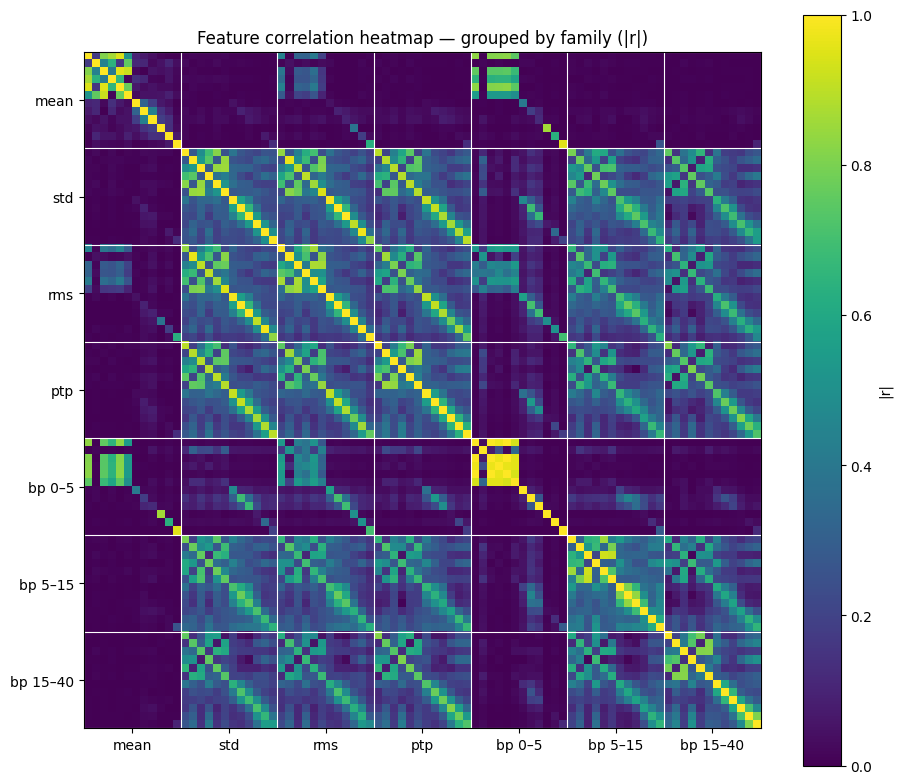


Top correlated pairs (|r|):


,,|r|
L1_bp_0_5Hz,L5_bp_0_5Hz,0.998851
L3_bp_0_5Hz,L5_bp_0_5Hz,0.997631
L8_std,L8_rms,0.997324
L9_std,L9_rms,0.997158
L1_bp_0_5Hz,L3_bp_0_5Hz,0.994845
L7_std,L7_rms,0.987335
L11_std,L11_rms,0.980248
L1_bp_0_5Hz,L4_bp_0_5Hz,0.975482
L3_bp_0_5Hz,L4_bp_0_5Hz,0.970156
L2_std,L2_rms,0.968515



Pruned features (|r|≥0.95): dropped 10 of 84 columns.


,dropped,kept,|r|
9,L5_bp_0_5Hz,L1_bp_0_5Hz,0.998851
4,L8_rms,L8_std,0.997324
5,L9_rms,L9_std,0.997158
7,L3_bp_0_5Hz,L1_bp_0_5Hz,0.994845
3,L7_rms,L7_std,0.987335
6,L11_rms,L11_std,0.980248
8,L4_bp_0_5Hz,L1_bp_0_5Hz,0.975482
2,L2_rms,L2_std,0.968515
0,L5_mean,L3_mean,0.956050
1,L12_bp_0_5Hz,L12_mean,0.955106


Saved: test/artifacts/figs/eda_feature_corr_heatmap_pruned.png


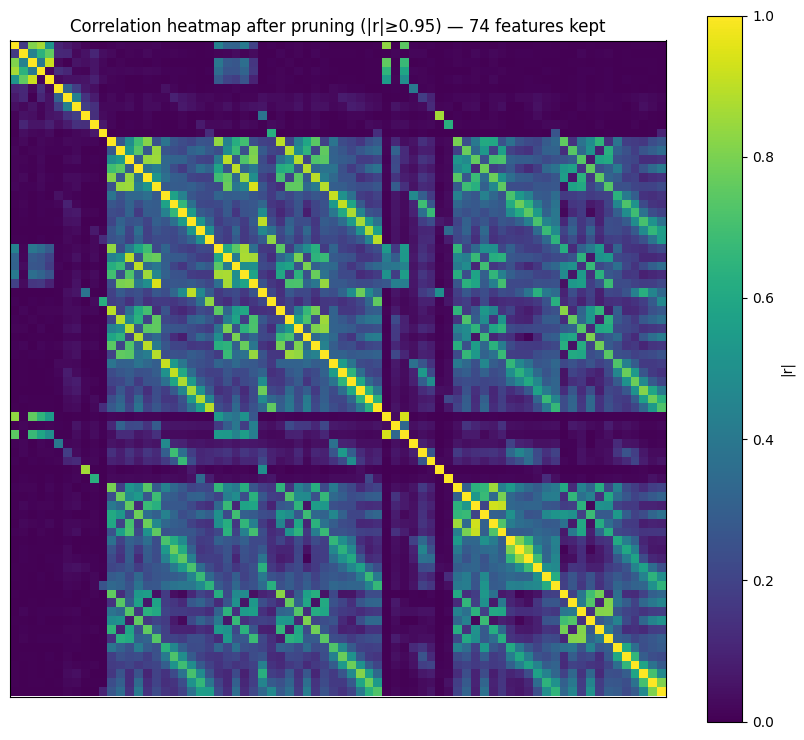

In [29]:
# %%
# 6b) EDA — correlations, imbalances & anomalies (simple heatmap version)

import numpy as np, pandas as pd, matplotlib.pyplot as plt

# --- Output folder helper (compatible with your earlier _save)
try:
    ART_DIR
except NameError:
    from pathlib import Path
    ART_DIR = Path("test/artifacts") / "figs"
    ART_DIR.mkdir(parents=True, exist_ok=True)

try:
    _save
except NameError:
    def _save(fig, name):
        out = ART_DIR / name
        fig.savefig(out, dpi=300, bbox_inches="tight")
        print("Saved:", out)

# --- Base table from §5
assert "features_df" in globals(), "Run §5 to create features_df first."
edf = features_df.copy()
labs = edf["label"].astype(str)

# ===== 1) Class imbalance =====
cls_counts = labs.value_counts().sort_index()
n = int(cls_counts.sum())
imb_ratio = (cls_counts.max() / cls_counts.min()) if cls_counts.min() > 0 else np.inf
p = cls_counts / n
gini = 1.0 - np.sum(p**2)
entropy = float(-(p.replace(0, np.nan) * np.log2(p.replace(0, np.nan))).sum())
maj_baseline = cls_counts.max() / n

print("=== Class imbalance ===")
display(pd.DataFrame({"count": cls_counts, "percent": (100*cls_counts/n).round(2)}))
print(f"Imbalance ratio (max/min): {imb_ratio:.2f}")
print(f"Gini-like index (1-∑p²):    {gini:.3f}   (higher → more uniform)")
print(f"Entropy (bits):              {entropy:.3f} (higher → more uniform)")
print(f"Majority baseline accuracy:  {maj_baseline:.3f}")

# ===== 2) Sex × Class association (χ² + Cramér’s V) =====
if "sex" in edf.columns:
    def _sex_norm(series: pd.Series) -> pd.Series:
        out = pd.Series("unknown", index=series.index, dtype="string")
        s_num = pd.to_numeric(series, errors="coerce")
        out.loc[s_num == 1] = "male"; out.loc[s_num == 0] = "female"
        s = series.astype("string").str.strip().str.lower()
        out.loc[s.str.startswith("m", na=False)] = "male"
        out.loc[s.str.startswith("f", na=False)] = "female"
        out.loc[s.isin({"male","man"})] = "male"
        out.loc[s.isin({"female","woman"})] = "female"
        return out

    edf["sex_norm"] = _sex_norm(edf["sex"])
    ct = pd.crosstab(edf["label"].astype(str), edf["sex_norm"])
    print("\n=== Sex × Class contingency ==="); display(ct)

    try:
        from scipy.stats import chi2_contingency
        chi2, pval, dof, _ = chi2_contingency(ct)
        n_ct = ct.values.sum()
        r, k = ct.shape
        cramers_v = np.sqrt((chi2 / n_ct) / max(1, (min(r-1, k-1))))
        print(f"χ²={chi2:.2f}, df={dof}, p={pval:.4g}  |  Cramér’s V={cramers_v:.3f}")
        if pval < 0.05: print("→ Association is statistically significant at α=0.05.")
    except Exception:
        print("(χ² skipped — SciPy not available)")

# ===== 3) Age differences across classes (ANOVA/Kruskal) =====
if "age" in edf.columns:
    age = pd.to_numeric(edf["age"], errors="coerce")
    by_class = {c: age[labs == c].dropna().values for c in sorted(labs.unique())}
    print("\n=== Age summary by class ===")
    display(pd.DataFrame({
        c: pd.Series({"n": len(v), "mean": np.mean(v) if len(v) else np.nan,
                      "std": np.std(v, ddof=1) if len(v)>1 else np.nan,
                      "median": np.median(v) if len(v) else np.nan})
        for c, v in by_class.items()
    }).T)

    nonempty = [v for v in by_class.values() if len(v) >= 5]
    if len(nonempty) >= 2:
        try:
            from scipy.stats import f_oneway, kruskal
            if all(len(v) >= 20 for v in nonempty):
                stat, pval = f_oneway(*nonempty); test_name = "One-way ANOVA"
            else:
                stat, pval = kruskal(*nonempty);  test_name = "Kruskal–Wallis"
            print(f"{test_name}: stat={stat:.2f}, p={pval:.4g}")
            if pval < 0.05: print("→ Age distributions differ significantly across classes (α=0.05).")
        except Exception:
            print("(Stat test skipped — SciPy not available)")

# ----- 4) Engineered features — simple, labeled heatmap + optional pruned view -----
if "feature_df" in globals():
    import re
    num = feature_df.drop(columns=["label"], errors="ignore").select_dtypes(include=[np.number])
    if num.shape[1] >= 2:

        # --- Parse columns into families for clean ordering ---
        # Matches: L{lead}_{mean|std|rms|ptp}  and  L{lead}_bp_{lo}_{hi}Hz
        def parse_col(c):
            m = re.match(r"L(\d+)_(mean|std|rms|ptp)$", c)
            if m:  # stats family
                return ("stat", m.group(2), int(m.group(1)))
            m = re.match(r"L(\d+)_bp_(\d+)_(\d+)Hz$", c)
            if m:  # bandpower family
                band = f"bp{m.group(2)}_{m.group(3)}"  # e.g., bp0_5, bp5_15, bp15_40
                return ("bp", band, int(m.group(1)))
            return ("other", c, 999)

        families = [("stat","mean"),("stat","std"),("stat","rms"),("stat","ptp"),
                    ("bp","bp0_5"),("bp","bp5_15"),("bp","bp15_40")]

        cols = list(num.columns)
        parsed = [parse_col(c) for c in cols]

        # Order columns by family then lead (1..12), leave unknowns at the end
        order = []
        for kind, fam in families:
            for lead in range(1, 13):
                for c, p in zip(cols, parsed):
                    if p[0]==kind and p[1]==fam and p[2]==lead:
                        order.append(c)
        order += [c for c in cols if c not in order]  # any leftovers

        # --- Labeled heatmap (|r|) ---
        corr = num[order].corr().abs()
        fig, ax = plt.subplots(figsize=(9.5, 8.0))
        im = ax.imshow(corr.values, vmin=0, vmax=1, cmap="viridis", interpolation="nearest")
        cb = fig.colorbar(im, ax=ax); cb.set_label("|r|")
        ax.set_title("Feature correlation heatmap — grouped by family (|r|)")

        # Draw thin separators and place family labels once per block
        parsed_order = [parse_col(c) for c in order]
        fam_labels = ["mean","std","rms","ptp","bp 0–5","bp 5–15","bp 15–40"]
        ticks, pos = [], 0
        for (kind,fam), label in zip(families, fam_labels):
            size = sum(1 for p in parsed_order if p[0]==kind and p[1]==fam)
            if size:
                ax.axhline(pos-0.5, color="w", lw=0.8)
                ax.axvline(pos-0.5, color="w", lw=0.8)
                ticks.append(pos + size/2 - 0.5)
                pos += size
        ax.axhline(pos-0.5, color="w", lw=0.8); ax.axvline(pos-0.5, color="w", lw=0.8)
        ax.set_xticks(ticks); ax.set_xticklabels(fam_labels, rotation=0)
        ax.set_yticks(ticks); ax.set_yticklabels(fam_labels)
        plt.tight_layout(); _save(fig, "eda_feature_corr_heatmap_grouped_simple.png"); plt.show()

        # Print top correlated pairs to caption the figure
        a = corr
        mask = np.triu(np.ones_like(a, dtype=bool), k=1)
        pairs = pd.DataFrame({"|r|": a.where(mask).stack()}) \
                    .sort_values("|r|", ascending=False).head(15)
        print("\nTop correlated pairs (|r|):"); display(pairs)

        # --- Optional: correlation-pruned view (drops near-duplicates, |r|>=0.95) ---
        def corr_prune(df, thr=0.95):
            C = df.corr().abs()
            keep, dropped, seen = [], [], set()
            for c in C.columns:
                if c in seen: continue
                keep.append(c); seen.add(c)
                # mark any feature highly correlated with 'c' for dropping
                drop_mask = (C[c] >= thr) & (C.index != c)
                for d in C.index[drop_mask]:
                    if d not in seen:
                        seen.add(d)
                        dropped.append((d, c, float(C.loc[d, c])))
            dropped_df = pd.DataFrame(dropped, columns=["dropped","kept","|r|"]) \
                         .sort_values("|r|", ascending=False)
            return keep, dropped_df

        keep_cols, dropped_df = corr_prune(num[order], thr=0.95)
        print(f"\nPruned features (|r|≥0.95): dropped {len(dropped_df)} of {num.shape[1]} columns.")
        display(dropped_df.head(10))

        num_pruned = num[keep_cols]
        corr_p = num_pruned.corr().abs()
        fig, ax = plt.subplots(figsize=(8.5, 7.5))
        im = ax.imshow(corr_p.values, vmin=0, vmax=1, cmap="viridis", interpolation="nearest")
        fig.colorbar(im, ax=ax).set_label("|r|")
        ax.set_title(f"Correlation heatmap after pruning (|r|≥0.95) — {num_pruned.shape[1]} features kept")
        ax.set_xticks([]); ax.set_yticks([])
        plt.tight_layout(); _save(fig, "eda_feature_corr_heatmap_pruned.png"); plt.show()

    else:
        print("\n(Engineered features present, but not enough numeric columns for a correlation matrix.)")
else:
    print("\n(Engineered features table not found — run §5b to generate signal-stats features.)")


In [18]:
# %% [markdown]
# ## 7) One-hot reformatted view for EDA (fold/sex/etc.)

# %%
MIN_CONF = float(CFG["SCP_MIN_CONF"])

def _sets_from_scpdict(s):
    try: d = ast.literal_eval(s)
    except Exception: return set(), set()
    sup, sub = set(), set()
    for code, conf in d.items():
        code = str(code)
        if code in valid_codes and float(conf) >= MIN_CONF:
            sup.add(str(diag_only.loc[code, "diagnostic_class"]))
            sub.add(str(diag_only.loc[code, "diagnostic_subclass"]))
    return sup, sub

sup_sets, sub_sets = [], []
for s in db["scp_codes"].astype(str):
    a, b = _sets_from_scpdict(s)
    sup_sets.append(sorted(a)); sub_sets.append(sorted(b))

Y = pd.DataFrame({
    "diagnostic_superclass": sup_sets,
    "diagnostic_subclass":  sub_sets,
    "diagnostic_superclass_len": [len(a) for a in sup_sets],
    "diagnostic_subclass_len":  [len(b) for b in sub_sets],
    "strat_fold": db["strat_fold"].astype(int) if "strat_fold" in db.columns else 10,
}, index=db.index)

if "ecg_id" in db.columns: Y.index = db["ecg_id"]
_meta_candidates = ["age","sex","height","weight","nurse","site","device"]
feature_cols = [c for c in _meta_candidates if c in db.columns]
X = db[feature_cols].copy(); 
if "ecg_id" in db.columns: X.index = Y.index

sup_all = sorted({c for lst in sup_sets for c in lst})
sub_all = sorted({c for lst in sub_sets for c in lst})
for c in sup_all: Y[c] = 0
for c in sub_all: Y[f"sub_{c}"] = 0

def _mark_row(row):
    for s in row["diagnostic_superclass"]: row[s]=1
    for s in row["diagnostic_subclass"]:  row[f"sub_{s}"]=1
    return row

Y = Y.apply(_mark_row, axis=1)

def get_data_by_folds(folds, X, Y, onehot_cols, feats):
    folds = list(map(int, np.atleast_1d(folds)))
    fit = Y["strat_fold"].isin(folds).values
    xs = X.loc[fit].copy()
    ys = Y.loc[fit].copy()
    cols = list(feats) + list(onehot_cols) + ["strat_fold"]
    cols = [c for c in cols if c in ys.columns]
    return xs, ys[cols]

update_cols = sup_all + [f"sub_{c}" for c in sub_all]
x_all, y_all = get_data_by_folds(np.arange(1, 11), X, Y, update_cols, feature_cols)
print(f"x_all: {x_all.shape} | y_all: {y_all.shape}")
display(y_all.head(5))

x_all: (21799, 7) | y_all: (21799, 29)


,CD,HYP,MI,NORM,STTC,sub_AMI,sub_CLBBB,sub_CRBBB,sub_ILBBB,sub_IMI,...,sub_NORM,sub_NST_,sub_PMI,sub_RAO/RAE,sub_RVH,sub_SEHYP,sub_STTC,sub_WPW,sub__AVB,strat_fold
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,1,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,3
2,0,0,0,1,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,2
3,0,0,0,1,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,5
4,0,0,0,1,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,3
5,0,0,0,1,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,4


In [19]:
# %% [markdown]
# ## 8) Leakage-safe Split + stratified subsample

# %%
from sklearn.model_selection import GroupShuffleSplit

df = features_df.copy()
TARGET_COL = "label"

if "strat_fold" in df.columns and df["strat_fold"].notna().all():
    train_mask = df["strat_fold"].astype(int).isin(range(1,10))
    test_mask  = df["strat_fold"].astype(int) == 10
    log("Using PTB-XL strat_fold (1–9→train, 10→test).")
else:
    groups = df["patient_id"].values if "patient_id" in df.columns else np.arange(len(df))
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
    train_idx, test_idx = next(gss.split(df, df[TARGET_COL], groups))
    train_mask = df.index.isin(train_idx); test_mask = df.index.isin(test_idx)
    log("Using GroupShuffleSplit by patient_id.")

y_train = df.loc[train_mask, TARGET_COL].copy()
y_test  = df.loc[test_mask,  TARGET_COL].copy()
X_train = df.loc[train_mask, ["record_path"]].copy()
X_test  = df.loc[test_mask,  ["record_path"]].copy()
log(f"Train/Test sizes: {len(X_train)} / {len(X_test)}")

print("Train class counts:"); display(y_train.value_counts().sort_index().to_frame("count"))
print("\nTest class counts:"); display(y_test.value_counts().sort_index().to_frame("count"))

if "patient_id" in df.columns:
    tr_p = set(df.loc[X_train.index, "patient_id"]); te_p = set(df.loc[X_test.index, "patient_id"])
    overlap = tr_p & te_p
    print(f"\nPatient leakage check — overlap={len(overlap)}")

# Stratified subsample of TRAIN
MAX_FRAC = float(CFG["DEEP_MAX_TRAIN_FRAC"])
tr_idx, te_idx = pd.Index(X_train.index), pd.Index(X_test.index)
if 0 < MAX_FRAC < 1.0:
    y_tr_full = pd.Series(y_train).loc[tr_idx]
    keep_idx = []
    for lab, idxs in y_tr_full.groupby(y_tr_full).groups.items():
        idxs = pd.Index(idxs)
        n_keep = max(1, int(np.ceil(len(idxs)*MAX_FRAC)))
        keep_idx.extend(idxs.to_series().sample(n=n_keep, random_state=SEED).tolist())
    tr_idx = pd.Index(keep_idx)
    print(f"\n[Data] Stratified train subsample: {len(tr_idx)} of {len(y_tr_full)} rows ({MAX_FRAC:.0%})")
    subs_counts = pd.Series(y_train).loc[tr_idx].value_counts().sort_index()
    display(pd.DataFrame({'count': subs_counts}))
else:
    print("\n[Data] Using full training split.")

[2025-10-11 12:19:14] Using PTB-XL strat_fold (1–9→train, 10→test).
[2025-10-11 12:19:14] Train/Test sizes: 19230 / 2158
Train class counts:


,count
label,
CD,3076
HYP,1182
MI,3644
NORM,8312
STTC,3016



Test class counts:


,count
label,
CD,355
HYP,123
MI,405
NORM,931
STTC,344



Patient leakage check — overlap=0

[Data] Stratified train subsample: 15386 of 19230 rows (80%)


,count
label,
CD,2461
HYP,946
MI,2916
NORM,6650
STTC,2413


In [20]:
# 9) Optional Binary Switch (kept OFF — enforce multiclass)

# %%
def _is_integer_series(s):
    try: return pd.api.types.is_integer_dtype(s.dtype)
    except Exception: return False

def _to_binary_series(y_series: pd.Series, scheme: str):
    ys = y_series.astype(str)
    scheme = scheme.upper().replace("-", "_")

    def _norm_vs_all(ys_):
        if (ys_ == "NORM").any():
            return (ys_ != "NORM").astype(int), "ABNORMAL (not NORM)", "NORM vs ALL"
        maj = ys_.value_counts().idxmax()
        return (ys_ != maj).astype(int), f"not {maj}", f"NORM missing → '{maj}' vs ALL"

    def _norm_vs_hyp(ys_):
        if (ys_ == "HYP").any():
            return (ys_ == "HYP").astype(int), "HYP", "HYP vs not-HYP"
        yb, pos_name, base_msg = _norm_vs_all(ys_); return yb, pos_name, f"Fallback → {base_msg}"

    if scheme in {"NORM_VS_HYP","NORM_VS_HYPERTENSION","NORM_VS_HYPER"}:
        return _norm_vs_hyp(ys)
    return _norm_vs_all(ys)

if bool(CFG["BINARY_TASK"]):
    # unchanged if ever flipped ON again
    scheme = str(CFG["BINARY_SCHEME"])
    y_train = pd.Series(y_train); y_test = pd.Series(y_test)
    if _is_integer_series(y_train) and _is_integer_series(y_test):
        y_train_bin = (y_train.astype(int) != 0).astype(int)
        y_test_bin  = (y_test.astype(int)  != 0).astype(int)
        pos_name, msg = "1", "labels numeric; using 1 as positive"
    else:
        y_train_bin, pos_name, msg_tr = _to_binary_series(y_train, scheme)
        y_test_bin,  _,        msg_te = _to_binary_series(y_test,  scheme)
        msg = f"{msg_tr} | test: {msg_te}"

    tr_vals = set(pd.Series(y_train_bin).loc[tr_idx].unique())
    te_vals = set(pd.Series(y_test_bin ).loc[te_idx].unique())
    ok = (tr_vals == {0,1}) and (te_vals == {0,1})

    if not ok:
        log("[Binary] ABORT — need both classes in train/test after subsample. Keeping multiclass.")
        CFG["BINARY_TASK"] = False
        CFG["BCE_POS_WEIGHT"] = None
    else:
        y_train, y_test = y_train_bin, y_test_bin
        CFG["POSITIVE_CLASS_NAME"] = pos_name
        log(f"Binary ON — {msg} | positive={pos_name}")
        tr_series = pd.Series(y_train).loc[tr_idx].astype(int)
        pos = int((tr_series == 1).sum()); neg = int((tr_series == 0).sum())
        CFG["BCE_POS_WEIGHT"] = float(neg / pos) if pos>0 else None
else:
    CFG["BCE_POS_WEIGHT"] = None
    log("Binary OFF — multiclass (5-class) kept.")

print("\nLabel summary (post-9):")
display(pd.Series(y_train).value_counts().sort_index().to_frame("train_count"))
display(pd.Series(y_test ).value_counts().sort_index().to_frame("test_count"))


[2025-10-11 12:19:14] Binary OFF — multiclass (5-class) kept.

Label summary (post-9):


,train_count
label,
CD,3076
HYP,1182
MI,3644
NORM,8312
STTC,3016


,test_count
label,
CD,355
HYP,123
MI,405
NORM,931
STTC,344


In [21]:
# %% [markdown]
# ## 10) PyTorch Runtime (Apple M-series/CUDA/CPU) — notebook-safe

# %%
import os, math, multiprocessing as mp

# --- Sanitize MPS watermarks BEFORE importing torch (prevents ratio errors) ---
def _sanitize_mps_env():
    hi_def = float(CFG.get("MPS_HIGH_WM", 0.92))
    lo_def = float(CFG.get("MPS_LOW_WM", 0.65))
    def _num(env, default):
        v = os.environ.get(env)
        if v is None: return default
        try: return float(v)
        except: return default
    hi = _num("PYTORCH_MPS_HIGH_WATERMARK_RATIO", hi_def)
    lo = _num("PYTORCH_MPS_LOW_WATERMARK_RATIO",  lo_def)
    if not (0.0 < hi < 1.0): hi = hi_def
    if not (0.0 < lo < 1.0): lo = lo_def
    if not (lo < hi): lo = max(0.05, min(hi - 0.05, 0.80))
    os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = f"{hi:.2f}"
    os.environ["PYTORCH_MPS_LOW_WATERMARK_RATIO"]  = f"{lo:.2f}"
    print(f"[MPS] LOW={os.environ['PYTORCH_MPS_LOW_WATERMARK_RATIO']}, "
          f"HIGH={os.environ['PYTORCH_MPS_HIGH_WATERMARK_RATIO']} (sanitized)")
_sanitize_mps_env()

import torch
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset

# Prefer MPS on Apple Silicon, then CUDA, else CPU (with robust fallback)
def _pick_device():
    if torch.backends.mps.is_available():
        try:
            dev = torch.device("mps")
            _ = torch.empty(1, device=dev)  # probe
            return dev
        except Exception as e:
            print(f"[Torch] MPS not usable, falling back. Reason: {e}")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

DEVICE = _pick_device()

# AMP only on CUDA
USE_AMP = (DEVICE.type == "cuda") and bool(CFG.get("TORCH_AMP", True))
SCALER = torch.cuda.amp.GradScaler(enabled=USE_AMP)

def empty_cache():
    try:
        if DEVICE.type == "cuda": torch.cuda.empty_cache()
        elif DEVICE.type == "mps": torch.mps.empty_cache()
    except Exception:
        pass

# ---- Centralized DataLoader heuristics ---------------------------------------
def _decide_loader_params():
    cpu_count = max(1, mp.cpu_count() - 1)
    nw  = CFG.get("NUM_WORKERS", None)
    pf  = CFG.get("PREFETCH_FACTOR", None)
    pin = CFG.get("PIN_MEMORY", None)
    if nw is None:
        if CFG.get("LOW_RAM", False):
            nw = 0
        else:
            nw = 2 if DEVICE.type == "mps" else min(4, cpu_count)
    if pf is None:
        pf = 2 if int(nw) > 0 else None
    if pin is None:
        pin = (DEVICE.type == "cuda")
    return int(nw), pf, bool(pin)

# Base suggestion...
NUM_WORKERS, PREFETCH_FACTOR, PIN_MEMORY = _decide_loader_params()

# --- Notebook-safe override to avoid pickling custom Datasets in worker procs ---
# Fixes: AttributeError: Can't get attribute 'ECGDataset' on __main__
NUM_WORKERS = 0
PREFETCH_FACTOR = None
PIN_MEMORY = False  # pinning only helps on CUDA; safe to disable on MPS/CPU

def loader_kwargs(shuffle: bool, batch_size: int):
    kw = dict(
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        drop_last=False,
    )
    # prefetch_factor only valid if num_workers > 0
    if NUM_WORKERS > 0 and PREFETCH_FACTOR is not None:
        kw.update(persistent_workers=True, prefetch_factor=int(PREFETCH_FACTOR))
    return kw

try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass

print(
    f"[Torch] device={DEVICE} | amp={USE_AMP} | torch={torch.__version__} | "
    f"workers={NUM_WORKERS} pin_memory={PIN_MEMORY} prefetch={PREFETCH_FACTOR}"
)


[MPS] LOW=0.65, HIGH=0.92 (sanitized)
[Torch] device=mps | amp=False | torch=2.8.0 | workers=0 pin_memory=False prefetch=None


In [22]:
# %% [markdown]
# ## 11) Data Pipeline (Dataset/DataLoader)

# %%
import wfdb
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedShuffleSplit

SEQ_LEN   = int(CFG["SEQ_LEN"])
DS_FACTOR = int(CFG["DOWNSAMPLE_FACTOR"])
BATCH     = int(CFG["BATCH_SIZE"])
VAL_FRAC  = 0.10
SEED      = CFG["SEED"]

train_paths = df.loc[tr_idx, "record_path"].astype(str).values
test_paths  = df.loc[te_idx, "record_path"].astype(str).values
assert len(train_paths) and len(test_paths), "Empty train/test paths."

# Union-fit LabelEncoder so test aligns
y_tr_series = pd.Series(y_train).loc[tr_idx]
y_te_series = pd.Series(y_test ).loc[te_idx]
union_labels = pd.Index(pd.concat([y_tr_series, y_te_series]), name="label").unique()
le = LabelEncoder().fit(union_labels)
y_tr = le.transform(y_tr_series.values)
y_te = le.transform(y_te_series.values)
n_classes = len(le.classes_)
is_binary = (n_classes == 2)
print(f"[Data] Classes: {list(le.classes_)} | binary={is_binary}")

# WFDB loader
STD_LEADS = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]
T_EFF = max(1, SEQ_LEN // max(1, DS_FACTOR))

def _load_ecg_numpy(rec_path: str, T=T_EFF, factor=DS_FACTOR):
    x, meta = wfdb.rdsamp(rec_path)   # x: (samples, channels)
    x = x.astype("float32")
    try:
        sig_names = meta.get("sig_name", [])
        if len(sig_names) >= 12 and all(s in sig_names for s in STD_LEADS):
            idx = [sig_names.index(s) for s in STD_LEADS]
            x = x[:, idx]
    except Exception:
        pass
    if factor > 1: x = x[::factor]
    if x.shape[0] >= T:
        x = x[:T, :]
    else:
        pad = np.zeros((T - x.shape[0], x.shape[1]), dtype="float32")
        x = np.vstack([x, pad])
    return x  # (T, C)

# Probe channels
_probe = None
for p in list(train_paths[:16]) + list(test_paths[:8]):
    try:
        _probe = _load_ecg_numpy(p); break
    except Exception:
        continue
assert _probe is not None, "Unable to infer channel count."
INPUT_T, INPUT_C = int(_probe.shape[0]), int(_probe.shape[1])
print(f"[Data] Sample shape: (T={INPUT_T}, C={INPUT_C})")

class ECGDataset(Dataset):
    def __init__(self, paths, y=None):
        self.paths = list(paths)
        self.labels = None if y is None else np.asarray(y, dtype=np.int64)
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        x = _load_ecg_numpy(self.paths[i])
        if self.labels is None: return torch.from_numpy(x)
        return torch.from_numpy(x), int(self.labels[i])

# --- Stratified, shuffled train/val split (fixes degenerate validation) ---
sss = StratifiedShuffleSplit(n_splits=1, test_size=VAL_FRAC, random_state=SEED)
all_pos = np.arange(len(y_tr))
tr_pos, va_pos = next(sss.split(all_pos, y_tr))

train_ds = ECGDataset(train_paths[tr_pos], y_tr[tr_pos])
val_ds   = ECGDataset(train_paths[va_pos],  y_tr[va_pos])
test_ds  = ECGDataset(test_paths,           None)

# Centralized DataLoader creation
train_loader = DataLoader(train_ds, **loader_kwargs(True,  BATCH))
val_loader   = DataLoader(val_ds,   **loader_kwargs(False, BATCH))

DEEP_TEST_PATHS = test_paths
print("[Data] Datasets — train:", len(train_ds), "val:", len(val_ds), "test:", len(test_ds))

# (Optional) sanity check: class balance in train/val
try:
    tr_counts = pd.Series(y_tr[tr_pos]).value_counts().sort_index()
    va_counts = pd.Series(y_tr[va_pos]).value_counts().sort_index()
    disp = pd.DataFrame({"train": tr_counts, "val": va_counts}).fillna(0).astype(int)
    print("\n[Data] Train/Val label counts (encoded):"); display(disp)
except Exception as _:
    pass

# (Optional) CE class weights for multiclass (ignored in binary)
if not is_binary:
    counts = np.bincount(y_tr, minlength=n_classes).astype(np.float64)
    total = counts.sum()
    with np.errstate(divide='ignore', invalid='ignore'):
        weights = (total / (n_classes * np.maximum(counts, 1.0)))
    CFG["CE_CLASS_WEIGHTS"] = weights.tolist()


[Data] Classes: ['CD', 'HYP', 'MI', 'NORM', 'STTC'] | binary=False
[Data] Sample shape: (T=300, C=12)
[Data] Datasets — train: 13847 val: 1539 test: 2158

[Data] Train/Val label counts (encoded):


,train,val
0,2215,246
1,851,95
2,2624,292
3,5985,665
4,2172,241


In [ ]:
# %% [markdown]
# ## 12) Models + Trainer (CNN/RNN/LSTM/ANN)

# %%
import math, time
from torch.nn.utils import clip_grad_norm_

def _head(in_features, n_classes, binary=False):
    return nn.Linear(in_features, 1 if binary else n_classes)

class CNN1D(nn.Module):
    def __init__(self, n_classes, binary=False):
        super().__init__()
        self.binary = binary
        self.avg2 = nn.AvgPool1d(2)
        self.body = nn.Sequential(
            nn.Conv1d(INPUT_C, 32, 7, padding=3), nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, 5, padding=2),     nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64,128, 3, padding=1),     nn.BatchNorm1d(128), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.fc = _head(128, n_classes, binary)
    def forward(self, x):
        x = x.permute(0,2,1)
        x = self.avg2(x)
        x = self.body(x).squeeze(-1)
        return self.fc(x)

class RNNsimple(nn.Module):
    def __init__(self, n_classes, binary=False):
        super().__init__()
        self.binary = binary
        self.rnn1 = nn.RNN(INPUT_C, 128, batch_first=True)
        self.drop = nn.Dropout(0.15)
        self.rnn2 = nn.RNN(128, 64, batch_first=True)
        self.fc1  = nn.Linear(64, 96)
        self.fc2  = _head(96, n_classes, binary)
    def forward(self, x):
        x = x[:, ::2, :]
        x, _ = self.rnn1(x)
        x = self.drop(x)
        x, _ = self.rnn2(x)
        x = x[:, -1, :]
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

class LSTM1D(nn.Module):
    def __init__(self, n_classes, binary=False):
        super().__init__()
        self.binary = binary
        self.l1 = nn.LSTM(INPUT_C, 128, batch_first=True)
        self.drop = nn.Dropout(0.15)
        self.l2 = nn.LSTM(128, 64, batch_first=True)
        self.fc1 = nn.Linear(64, 96)
        self.fc2 = _head(96, n_classes, binary)
    def forward(self, x):
        x = x[:, ::2, :]
        x, _ = self.l1(x)
        x = self.drop(x)
        x, _ = self.l2(x)
        x = x[:, -1, :]
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

class ANNpooled(nn.Module):
    def __init__(self, n_classes, binary=False):
        super().__init__()
        self.binary = binary
        self.fc = nn.Sequential(
            nn.Linear(INPUT_C, 256), nn.ReLU(), nn.Dropout(0.20),
            nn.Linear(256, 128),     nn.ReLU()
        )
        self.out = _head(128, n_classes, binary)
    def forward(self, x):
        x = x.mean(dim=1)     # global avg over T
        x = self.fc(x)
        return self.out(x)

def _build(model_name, n_classes, binary):
    name = model_name.lower()
    if name == "cnn":   return CNN1D(n_classes, binary)
    if name == "rnn":   return RNNsimple(n_classes, binary)
    if name == "lstm":  return LSTM1D(n_classes, binary)
    if name == "ann":   return ANNpooled(n_classes, binary)
    raise ValueError("Unknown model: " + model_name)

# --- UPDATED: use BCE pos_weight when binary; optional CE class weights when multiclass ---
def _criterion(binary):
    if binary:
        pw = CFG.get("BCE_POS_WEIGHT", None)
        if pw and float(pw) > 0:
            return nn.BCEWithLogitsLoss(pos_weight=torch.tensor([float(pw)], device=DEVICE))
        return nn.BCEWithLogitsLoss()
    else:
        cw = CFG.get("CE_CLASS_WEIGHTS", None)
        if cw is not None:
            w = torch.tensor(cw, dtype=torch.float32, device=DEVICE)
            return nn.CrossEntropyLoss(weight=w)
        return nn.CrossEntropyLoss()

@torch.no_grad()
def _eval_epoch(model, loader, binary):
    model.eval()
    total, correct, loss_sum = 0, 0, 0.0
    crit = _criterion(binary)
    for xb, yb in loader:
        xb = xb.to(DEVICE); yb = yb.to(DEVICE)
        logits = model(xb)
        loss = crit(logits.view(-1), yb.float()) if binary else crit(logits, yb)
        loss_sum += loss.item() * xb.size(0)
        preds = (torch.sigmoid(logits.view(-1)) >= 0.5).long() if binary else logits.argmax(1)
        correct += (preds == yb).sum().item()
        total   += xb.size(0)
    return (loss_sum/total if total else math.nan), (correct/total if total else math.nan)

def _lr_for(name: str):
    name = name.lower()
    if name in {"rnn","lstm","ann"}:
        return float(CFG.get("RECURRENT_LR", 2e-4))
    return float(CFG.get("BASE_LR", 3e-4))

def train_model_torch(name, epochs=int(CFG["EPOCHS"])):
    """Central trainer with early-stopping, grad clip, timing."""
    binary   = is_binary
    model    = _build(name, n_classes, binary).to(DEVICE)
    opt      = optim.Adam(model.parameters(), lr=_lr_for(name))
    sch      = optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=2, min_lr=1e-5)
    crit     = _criterion(binary)

    patience = int(CFG.get("EARLY_STOP_PATIENCE", 3) or 0)
    monitor  = str(CFG.get("EARLY_STOP_MONITOR", "acc")).lower()  # "acc" or "loss"
    max_norm = CFG.get("GRAD_CLIP_NORM", None)

    best_state = None
    best_val   = -1.0 if monitor == "acc" else float("inf")
    bad        = 0

    hist = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}
    t0 = time.time()

    for ep in range(1, epochs+1):
        model.train()
        ep_loss, ep_correct, ep_total = 0.0, 0, 0
        ep_t0 = time.time()
        for xb, yb in train_loader:
            xb = xb.to(DEVICE); yb = yb.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            if USE_AMP:
                with torch.cuda.amp.autocast():
                    logits = model(xb)
                    loss = crit(logits.view(-1), yb.float()) if binary else crit(logits, yb)
                SCALER.scale(loss).backward()
                if max_norm: SCALER.unscale_(opt); clip_grad_norm_(model.parameters(), float(max_norm))
                SCALER.step(opt); SCALER.update()
            else:
                logits = model(xb)
                loss = crit(logits.view(-1), yb.float()) if binary else crit(logits, yb)
                loss.backward()
                if max_norm: clip_grad_norm_(model.parameters(), float(max_norm))
                opt.step()

            ep_loss    += loss.item() * xb.size(0)
            preds = (torch.sigmoid(logits.view(-1)) >= 0.5).long() if binary else logits.argmax(1)
            ep_correct += (preds == yb).sum().item()
            ep_total   += xb.size(0)

        tr_loss = ep_loss / max(1, ep_total)
        tr_acc  = ep_correct / max(1, ep_total)
        val_loss, val_acc = _eval_epoch(model, val_loader, binary)

        hist["loss"].append(tr_loss); hist["accuracy"].append(tr_acc)
        hist["val_loss"].append(val_loss); hist["val_accuracy"].append(val_acc)
        sch.step(val_loss if not math.isnan(val_loss) else tr_loss)

        ep_time = time.time() - ep_t0
        print(f"[{name}] epoch {ep:02d}/{epochs}  "
              f"loss={tr_loss:.4f} acc={tr_acc:.4f}  "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}  "
              f"({ep_time:.2f}s)")

        # Early stopping logic
        score = val_acc if monitor == "acc" else -val_loss
        best_score = best_val if monitor == "acc" else -best_val
        if score > best_score:
            best_val = val_acc if monitor == "acc" else val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if patience and bad >= patience:
                print(f"[{name}] Early stopping (patience={patience}, monitor='{monitor}').")
                break

    total_time = time.time() - t0
    if best_state is not None:
        model.load_state_dict(best_state)

    # Attach a tiny metadata bundle to history
    hist["_meta"] = {
        "epochs_trained": len(hist["loss"]),
        "best_val_acc":   max(hist["val_accuracy"]) if hist["val_accuracy"] else math.nan,
        "best_val_loss":  min(hist["val_loss"])     if hist["val_loss"]     else math.nan,
        "lr": _lr_for(name),
        "monitor": monitor,
        "patience": patience,
        "grad_clip_norm": max_norm,
        "time_sec_total": total_time,
    }
    return model, hist


In [ ]:
# %% [markdown]
# ## 13) Train Selected Models

# %%
deep_models_raw, histories = {}, {}
rows = []

def _train_if(flag, name):
    if not flag:
        print(f"[Train] Skipped {name.upper()} (flag off)")
        return

    # Clear device caches before/after to avoid OOM hitches (CUDA/MPS-safe)
    try: empty_cache()
    except Exception: pass

    print(f"\n[Train] === {name.upper()} ===")
    try:
        m, h = train_model_torch(name)
    except Exception as e:
        print(f"[Train] {name.upper()} failed: {e}")
        return

    deep_models_raw[f"{name.upper()} (PyTorch)"] = m
    histories[f"{name.upper()} (PyTorch)"] = h

    meta = h.get("_meta", {})
    rows.append({
        "model": f"{name.upper()} (PyTorch)",
        "epochs": meta.get("epochs_trained"),
        "best_val_acc": meta.get("best_val_acc"),
        "best_val_loss": meta.get("best_val_loss"),
        "lr": meta.get("lr"),
        "monitor": meta.get("monitor"),
        "patience": meta.get("patience"),
        "grad_clip_norm": meta.get("grad_clip_norm"),
        "time_sec_total": meta.get("time_sec_total"),
    })

    try: empty_cache()
    except Exception: pass

_train_if(CFG["RUN_TORCH_CNN"],  "cnn")
_train_if(CFG["RUN_TORCH_RNN"],  "rnn")
_train_if(CFG["RUN_TORCH_LSTM"], "lstm")
_train_if(CFG["RUN_TORCH_ANN"],  "ann")

print("\n[Models] Ready:", list(deep_models_raw.keys()))
if rows:
    # Sort by quality (best validation accuracy) to quickly spot the winner
    train_summary_df = pd.DataFrame(rows).sort_values("best_val_acc", ascending=False)
    print("\n[Train] Summary (sorted by best val_acc):")
    display(train_summary_df)
else:
    train_summary_df = pd.DataFrame()



[Train] === CNN ===
[cnn] epoch 01/12  loss=1.1933 acc=0.5845  val_loss=1.0255 val_acc=0.6524  (31.17s)
[cnn] epoch 02/12  loss=1.0115 acc=0.6550  val_loss=0.9915 val_acc=0.6927  (28.73s)
[cnn] epoch 03/12  loss=0.9639 acc=0.6743  val_loss=0.9705 val_acc=0.6725  (28.37s)
[cnn] epoch 04/12  loss=0.9225 acc=0.6860  val_loss=0.9413 val_acc=0.6667  (29.24s)
[cnn] epoch 05/12  loss=0.9024 acc=0.6913  val_loss=0.9912 val_acc=0.7135  (30.04s)
[cnn] epoch 06/12  loss=0.8763 acc=0.6978  val_loss=0.9158 val_acc=0.6953  (32.25s)
[cnn] epoch 07/12  loss=0.8640 acc=0.7006  val_loss=0.8966 val_acc=0.6738  (31.24s)
[cnn] epoch 08/12  loss=0.8525 acc=0.7067  val_loss=0.9185 val_acc=0.7212  (31.05s)
[cnn] epoch 09/12  loss=0.8339 acc=0.7133  val_loss=0.8775 val_acc=0.6933  (28.49s)
[cnn] epoch 10/12  loss=0.8145 acc=0.7157  val_loss=0.9052 val_acc=0.6693  (30.18s)
[cnn] epoch 11/12  loss=0.8024 acc=0.7260  val_loss=0.9398 val_acc=0.7102  (29.32s)
[cnn] Early stopping (patience=3, monitor='acc').

[Tra

In [ ]:
# %%
# 12b) Baseline model (DummyClassifier) on engineered features

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np, pandas as pd

def _load_feature_table():
    out = Path(CFG["ART_DIR"]) / CFG.get("FEATURES_CSV_NAME", "basic_signal_features.csv")
    if out.exists():
        return pd.read_csv(out, index_col=0)
    if "feature_df" in globals():
        return feature_df.copy()
    raise FileNotFoundError("No feature table found. Run 5b) first.")

if CFG.get("RUN_BASELINE_DUMMY", True):
    feats = _load_feature_table()
    # Split to train/test using your existing indices
    X_tr = feats.loc[feats.index.intersection(tr_idx)].drop(columns=["label"], errors="ignore")
    y_tr_b = feats.loc[X_tr.index, "label"].astype(str)
    X_te = feats.loc[feats.index.intersection(te_idx)].drop(columns=["label"], errors="ignore")
    y_te_b = feats.loc[X_te.index, "label"].astype(str)

    # numeric-only
    X_tr = X_tr.select_dtypes(include=[np.number]).copy()
    X_te = X_te.select_dtypes(include=[np.number]).copy()

    pipe = Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("sc", StandardScaler(with_mean=False)),   # safe for sparse-ish, fast
        ("clf", DummyClassifier(strategy="most_frequent"))
    ])
    pipe.fit(X_tr, y_tr_b)
    y_pred = pipe.predict(X_te)

    row = {
        "model": "Baseline Dummy (most_frequent)",
        "accuracy": accuracy_score(y_te_b, y_pred),
        "precision_macro": precision_score(y_te_b, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_te_b, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_te_b, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_te_b, y_pred, average="weighted", zero_division=0),
        "roc_auc_ovr_macro": np.nan  # not meaningful for constant-proba Dummy
    }

    # append/merge into unified_df if present; else create
    baseline_df = pd.DataFrame([row])
    if "unified_df" in globals() and len(unified_df):
        unified_df = pd.concat([unified_df, baseline_df], ignore_index=True).sort_values("f1_weighted", ascending=False)
    else:
        unified_df = baseline_df
    print("\n[Baseline] Added to unified evaluation:"); display(unified_df)
else:
    print("[Baseline] Skipped (RUN_BASELINE_DUMMY=False).")



[Baseline] Added to unified evaluation:


,model,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,roc_auc_ovr_macro
0,Baseline Dummy (most_frequent),0.431418,0.086284,0.2,0.120557,0.260052,NaN


In [26]:
# %% [markdown]
# ## 13b) Tiny Hyper-Parameter Search (Random) — per model on the same train/val split

# %%
import itertools, time, math
import numpy as np
from copy import deepcopy
from torch.nn.utils import clip_grad_norm_
import torch
from torch.utils.data import Dataset, DataLoader

# --- Shim: define TorchAdapter if §15 hasn't run yet ---
try:
    TorchAdapter  # noqa: F821
except NameError:
    class _PredictOnly(Dataset):
        def __init__(self, paths): self.paths=list(paths)
        def __len__(self): return len(self.paths)
        def __getitem__(self, i): return torch.from_numpy(_load_ecg_numpy(self.paths[i]))

    class TorchAdapter:
        def __init__(self, model, label_encoder, is_binary: bool, batch=32):
            self.model = model.to(DEVICE).eval()
            self.le = label_encoder
            self.is_binary = is_binary
            self.batch = int(batch)
            self.classes_ = getattr(self.le, "classes_", None)

        @torch.no_grad()
        def _loader(self, paths):
            ds = _PredictOnly(paths)
            return DataLoader(ds, **loader_kwargs(False, self.batch))

        @torch.no_grad()
        def predict(self, paths):
            preds = []
            for xb in self._loader(paths):
                xb = xb.to(DEVICE); logits = self.model(xb)
                if self.is_binary:
                    y_idx = (torch.sigmoid(logits.view(-1)) >= 0.5).long().cpu().numpy()
                else:
                    y_idx = logits.argmax(1).cpu().numpy()
                preds.extend(self.le.inverse_transform(np.asarray(y_idx)))
            return np.asarray(preds)

        @torch.no_grad()
        def predict_proba(self, paths):
            out = []
            for xb in self._loader(paths):
                xb = xb.to(DEVICE); logits = self.model(xb)
                if self.is_binary:
                    p1 = torch.sigmoid(logits.view(-1)).unsqueeze(1)
                    p0 = 1.0 - p1
                    p = torch.cat([p0, p1], dim=1)
                else:
                    p = torch.softmax(logits, dim=1)
                out.append(p.cpu().numpy().astype("float32"))
            return np.vstack(out)

# --- Helpers to rebuild loaders with different batch sizes ---
def _make_loaders(batch_size: int):
    return (
        DataLoader(train_ds, **loader_kwargs(True,  int(batch_size))),
        DataLoader(val_ds,   **loader_kwargs(False, int(batch_size))),
    )

def _fit_for_epochs_with_hp(model, dl_tr, dl_va, epochs, lr, wd=0.0, patience=2, max_norm=None):
    model = model.to(DEVICE)
    crit = _criterion(is_binary)
    opt  = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    sch  = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=1, min_lr=1e-5)
    best_state, best_val = None, float("inf")
    bad = 0
    for ep in range(1, int(epochs)+1):
        model.train(); ep_loss = 0.0; n = 0
        for xb, yb in dl_tr:
            xb=xb.to(DEVICE); yb=yb.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = crit(logits.view(-1), yb.float()) if is_binary else crit(logits, yb)
            loss.backward()
            if max_norm: clip_grad_norm_(model.parameters(), float(max_norm))
            opt.step()
            ep_loss += loss.item() * xb.size(0); n += xb.size(0)
        val_loss, _ = _eval_epoch(model, dl_va, is_binary)
        sch.step(val_loss if not math.isnan(val_loss) else ep_loss/max(1,n))
        # early stopping on val_loss
        if val_loss < best_val:
            best_val = val_loss; best_state = deepcopy(model.state_dict()); bad = 0
        else:
            bad += 1
            if patience and bad >= patience: break
    if best_state is not None: model.load_state_dict(best_state)
    return model

def random_search_models(trials=8, epochs=4):
    """
    Randomly try small sets of (batch, lr, weight_decay) for each selected model.
    Keeps best by validation accuracy.
    """
    rng = np.random.RandomState(SEED)
    search_space = {
        "batch":        [16, 24, 32],
        "lr":           [1e-4, 2e-4, 3e-4, 5e-4, 1e-3],
        "weight_decay": [0.0, 1e-5, 5e-5, 1e-4],
        "patience":     [2, 3],
        "grad_clip":    [None, 1.0],
    }
    combos = list(itertools.product(search_space["batch"], search_space["lr"],
                                    search_space["weight_decay"], search_space["patience"],
                                    search_space["grad_clip"]))
    rng.shuffle(combos)
    combos = combos[:int(trials)]

    results = []
    def _try_one(model_name):
        best = {"val_acc": -1.0, "cfg": None, "state": None}
        for (batch, lr, wd, pat, gclip) in combos:
            dl_tr, dl_va = _make_loaders(batch)
            model = _build(model_name, n_classes, is_binary)
            model = _fit_for_epochs_with_hp(model, dl_tr, dl_va, epochs=epochs, lr=lr, wd=wd, patience=pat, max_norm=gclip)
            _, val_acc = _eval_epoch(model, dl_va, is_binary)
            if val_acc > best["val_acc"]:
                best.update(val_acc=float(val_acc),
                            cfg={"batch":int(batch),"lr":float(lr),"weight_decay":float(wd),
                                 "patience":int(pat),"grad_clip":(None if gclip is None else float(gclip))},
                            state=deepcopy(model.state_dict()))
        return best

    picked = {}
    for name, flag in [("cnn", CFG["RUN_TORCH_CNN"]), ("rnn", CFG["RUN_TORCH_RNN"]),
                       ("lstm", CFG["RUN_TORCH_LSTM"]), ("ann", CFG["RUN_TORCH_ANN"])]:
        if not flag: continue
        print(f"[HPO] {name.upper()} — {int(trials)} trials")
        best = _try_one(name)
        picked[name] = best
        results.append({"model": name.upper(), "best_val_acc": best["val_acc"], **(best["cfg"] or {})})

    hpo_df = pd.DataFrame(results).sort_values("best_val_acc", ascending=False)
    display(hpo_df)
    return picked, hpo_df

# Run small HPO (edit trials/epochs if needed)
HPO_TRIALS = 8 if not CFG.get("FAST_RUN", False) else 2
HPO_EPOCHS = 4 if not CFG.get("FAST_RUN", False) else 2
best_states, hpo_table = random_search_models(trials=HPO_TRIALS, epochs=HPO_EPOCHS)

# (optional) re-attach best states as adapters for unified evaluation later
if "deep_models" not in globals():
    deep_models = {}  # ensure dict exists

deep_models_hpo = {}
for name, best in best_states.items():
    if not best or best.get("state") is None: continue
    cfg = best["cfg"]; batch_for_eval = cfg.get("batch", 32)
    print(f"[HPO-FINAL] {name.upper()} with {cfg}")
    model = _build(name, n_classes, is_binary).to(DEVICE)
    model.load_state_dict(best["state"])
    deep_models_hpo[f"{name.upper()} (PyTorch, HPO)"] = TorchAdapter(model, le, is_binary, batch=batch_for_eval)

# merge into evaluation pool
deep_models.update(deep_models_hpo)
print("[HPO] Models added to evaluation:", list(deep_models_hpo.keys()))


[HPO] CNN — 8 trials


KeyboardInterrupt: 

In [ ]:
# %%
# 13c) Small Grid Search (ANN only): batch × lr × dropout

import itertools, copy, numpy as np, torch
from torch import nn, optim

def _build_ann_with_dropout(n_classes, binary, p_drop=0.20):
    class ANNdrop(nn.Module):
        def __init__(self):
            super().__init__()
            self.binary = binary
            self.fc = nn.Sequential(
                nn.Linear(INPUT_C, 256), nn.ReLU(), nn.Dropout(float(p_drop)),
                nn.Linear(256, 128),     nn.ReLU()
            )
            self.out = nn.Linear(128, 1 if binary else n_classes)
        def forward(self, x):
            x = x.mean(dim=1)
            x = self.fc(x)
            return self.out(x)
    return ANNdrop()

def _fit_quick(model, dl_tr, dl_va, epochs=3, lr=2e-4, max_norm=None):
    model = model.to(DEVICE)
    crit = _criterion(is_binary)
    opt  = optim.Adam(model.parameters(), lr=float(lr))
    best, best_acc = None, -1.0
    for _ in range(int(epochs)):
        model.train()
        for xb, yb in dl_tr:
            xb=xb.to(DEVICE); yb=yb.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = crit(logits.view(-1), yb.float()) if is_binary else crit(logits, yb)
            loss.backward()
            if max_norm: nn.utils.clip_grad_norm_(model.parameters(), float(max_norm))
            opt.step()
        _, va_acc = _eval_epoch(model, dl_va, is_binary)
        if va_acc > best_acc:
            best_acc = va_acc
            best = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
    if best is not None: model.load_state_dict(best)
    return model, best_acc

def grid_search_ann(grid=None, epochs=3):
    if grid is None:
        grid = {
            "batch":   [24, 32],
            "lr":      [1e-4, 2e-4, 3e-4],
            "dropout": [0.10, 0.20, 0.35],
            "grad_clip": [None, 1.0],
        }
    combos = list(itertools.product(grid["batch"], grid["lr"], grid["dropout"], grid["grad_clip"]))
    best = {"score": -1.0, "cfg": None, "state": None}
    for (b, lr, dp, gc) in combos:
        dl_tr, dl_va = _make_loaders(b)
        model = _build_ann_with_dropout(n_classes, is_binary, p_drop=dp)
        model, score = _fit_quick(model, dl_tr, dl_va, epochs=epochs, lr=lr, max_norm=gc)
        if score > best["score"]:
            best.update(score=float(score), cfg={"batch":int(b),"lr":float(lr),"dropout":float(dp),"grad_clip":gc},
                        state=copy.deepcopy(model.state_dict()))
    return best

if CFG.get("RUN_TORCH_ANN", True):
    print("[GRID] ANN small grid search…")
    gbest = grid_search_ann(epochs=(2 if CFG.get("FAST_RUN", False) else 3))
    print("[GRID] Best:", gbest["cfg"], "val_acc=", round(gbest["score"], 4))
    if gbest["state"] is not None:
        model = _build_ann_with_dropout(n_classes, is_binary, p_drop=gbest["cfg"]["dropout"]).to(DEVICE)
        model.load_state_dict(gbest["state"])
        # add to evaluation pool
        if "deep_models" not in globals():
            deep_models = {}
        deep_models["ANN (PyTorch, Grid)"] = TorchAdapter(model, le, is_binary, batch=gbest["cfg"]["batch"])
        print("[GRID] Added ANN (PyTorch, Grid) to evaluation pool.")
else:
    print("[GRID] Skipped (RUN_TORCH_ANN=False).")


In [ ]:
# %% [markdown]
# ## 14) K-Fold CV for ALL models (optional)

# %%
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time

if bool(CFG["RUN_KFOLD_ALL"]):
    K = int(CFG["KFOLDS"]); CV_EPOCHS = int(CFG["CV_EPOCHS"])
    print(f"[CV-ALL] {K}-fold for CNN/RNN/LSTM/ANN (epochs={CV_EPOCHS}) on TRAIN (subsampled).")

    tr_paths_full = df.loc[tr_idx, "record_path"].astype(str).values
    y_tr_enc_full = le.transform(pd.Series(y_train).loc[tr_idx].astype(str).values)

    class PairDS(Dataset):
        def __init__(self, paths, y): self.paths=list(paths); self.y=np.asarray(y, np.int64)
        def __len__(self): return len(self.paths)
        def __getitem__(self, i):
            x=_load_ecg_numpy(self.paths[i]); return torch.from_numpy(x), int(self.y[i])

    def _fit_for_epochs(model, dl_tr, dl_va, epochs=CV_EPOCHS):
        model = model.to(DEVICE)
        opt = optim.Adam(model.parameters(), lr=3e-4)
        crit = _criterion(is_binary)  # << use same weighting logic as main trainer
        best, best_acc = None, -1.0
        for _ in range(epochs):
            model.train()
            for xb, yb in dl_tr:
                xb=xb.to(DEVICE); yb=yb.to(DEVICE)
                opt.zero_grad(set_to_none=True)
                logits=model(xb)
                loss=crit(logits.view(-1), yb.float()) if is_binary else crit(logits, yb)
                loss.backward(); opt.step()
            va_loss, va_acc = _eval_epoch(model, dl_va, is_binary)
            if va_acc > best_acc:
                best_acc = va_acc; best = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
        if best is not None: model.load_state_dict(best)
        return model

    model_names = ["CNN","RNN","LSTM","ANN"]
    all_rows = []
    skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=SEED)
    for mdl_name in model_names:
        print(f"\n[CV-ALL] === {mdl_name} ===")
        start_m = time.time()
        rows = []
        for fold, (tr_i, va_i) in enumerate(skf.split(tr_paths_full, y_tr_enc_full), 1):
            ds_tr = PairDS(tr_paths_full[tr_i], y_tr_enc_full[tr_i])
            ds_va = PairDS(tr_paths_full[va_i], y_tr_enc_full[va_i])
            dl_tr = DataLoader(ds_tr, **loader_kwargs(True,  BATCH))
            dl_va = DataLoader(ds_va, **loader_kwargs(False, BATCH))
            t0 = time.time()
            model = _build(mdl_name, n_classes, is_binary)
            model = _fit_for_epochs(model, dl_tr, dl_va, CV_EPOCHS)
            t_fold = time.time() - t0

            # eval on val fold
            y_pred_idx = []
            with torch.no_grad():
                for xb, _ in dl_va:
                    xb=xb.to(DEVICE); logits=model(xb)
                    y_pred_idx.extend(((torch.sigmoid(logits.view(-1))>=0.5).long().cpu().numpy())
                                      if is_binary else logits.argmax(1).cpu().numpy())
            y_true_idx = y_tr_enc_full[va_i]
            y_pred = le.inverse_transform(np.array(y_pred_idx))
            y_true = le.inverse_transform(y_true_idx)

            rows.append({
                "model": mdl_name, "fold": fold,
                "accuracy": accuracy_score(y_true, y_pred),
                "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
                "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
                "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
                "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
                "time_sec": t_fold,
            })
            print(f"[CV-ALL] {mdl_name} fold {fold}/{K} time={t_fold:.2f}s")
        total_m = time.time() - start_m
        cv_df_m = pd.DataFrame(rows)
        print(f"[CV-ALL] {mdl_name} — per-fold:"); display(cv_df_m)
        print(f"[CV-ALL] {mdl_name} — mean±std:")
        display(cv_df_m.describe().loc[["mean","std"]][["time_sec","accuracy","precision_macro","recall_macro","f1_macro","f1_weighted"]])
        print(f"[CV-ALL] {mdl_name} — total time: {total_m:.2f}s")
        all_rows.extend(rows)
    cv_all_df = pd.DataFrame(all_rows); print("\n[CV-ALL] Combined:"); display(cv_all_df)
else:
    print("[CV-ALL] Skipped.")


In [ ]:
# %% [markdown]
# ## 15) Unified Evaluation Table (+ ROC-AUC)

# %%
from sklearn.metrics import (
    classification_report, accuracy_score, f1_score, precision_score,
    recall_score, confusion_matrix, roc_auc_score
)

class _PredictOnly(torch.utils.data.Dataset):
    def __init__(self, paths): self.paths=list(paths)
    def __len__(self): return len(self.paths)
    def __getitem__(self, i): return torch.from_numpy(_load_ecg_numpy(self.paths[i]))

class TorchAdapter:
    def __init__(self, model, label_encoder, is_binary: bool, batch=BATCH):
        self.model = model.to(DEVICE).eval()
        self.le = label_encoder; self.is_binary = is_binary; self.batch = batch
        self.classes_ = self.le.classes_
    @torch.no_grad()
    def _loader(self, paths):
        ds = _PredictOnly(paths)
        return DataLoader(ds, **loader_kwargs(False, self.batch))
    @torch.no_grad()
    def predict(self, paths):
        preds=[]
        for xb in self._loader(paths):
            xb=xb.to(DEVICE); logits=self.model(xb)
            y_idx=((torch.sigmoid(logits.view(-1))>=0.5).long().cpu().numpy()
                   if self.is_binary else logits.argmax(1).cpu().numpy())
            preds.extend(self.le.inverse_transform(y_idx))
        return np.asarray(preds)
    @torch.no_grad()
    def predict_proba(self, paths):
        out=[]
        for xb in self._loader(paths):
            xb=xb.to(DEVICE); logits=self.model(xb)
            if self.is_binary:
                p1=torch.sigmoid(logits.view(-1)).unsqueeze(1); p0=1.0-p1; p=torch.cat([p0,p1], dim=1)
            else:
                p=torch.softmax(logits, dim=1)
            out.append(p.cpu().numpy().astype("float32"))
        return np.vstack(out)

deep_models = {name: TorchAdapter(m, le, is_binary, batch=BATCH) for name, m in deep_models_raw.items()}

def _scores_or_none(model, X):
    try: return model.predict_proba(X), getattr(model, "classes_", None)
    except Exception: return None, None

def _align_scores_to_classes(scores, est_classes, target_classes):
    if scores is None or est_classes is None: return None
    est_classes = np.asarray(est_classes); target_classes = np.asarray(target_classes)
    pos = {c:i for i,c in enumerate(est_classes)}
    idx = []
    for c in target_classes:
        if c not in pos: return None
        idx.append(pos[c])
    return scores[:, idx]

def eval_model_to_row(name, model, X_in, y_true):
    y_pred = model.predict(X_in)
    y_scores, est_classes = _scores_or_none(model, X_in)
    row = {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "roc_auc_ovr_macro": np.nan
    }
    if y_scores is not None:
        classes = np.unique(y_true)
        if len(classes) > 1:
            from sklearn.preprocessing import label_binarize
            y_bin = label_binarize(y_true, classes=classes)
            y_scores_aligned = _align_scores_to_classes(y_scores, est_classes, classes)
            if y_scores_aligned is not None:
                try:
                    row["roc_auc_ovr_macro"] = float(
                        roc_auc_score(y_bin, y_scores_aligned, average="macro", multi_class="ovr")
                    )
                except Exception:
                    pass
    return row

eval_entries = list(deep_models.items())
if not eval_entries:
    print("No models to evaluate."); unified_df = pd.DataFrame()
else:
    rows = []
    for name, mdl in eval_entries:
        print(f"\n=== {name} ===")
        try:
            y_pred_tmp = mdl.predict(DEEP_TEST_PATHS)
            print(classification_report(y_test, y_pred_tmp, digits=3, zero_division=0))
        except Exception as e:
            print(f"(Per-class report skipped: {e})")
        rows.append(eval_model_to_row(name, mdl, DEEP_TEST_PATHS, y_test))
    unified_df = pd.DataFrame(rows).sort_values("f1_weighted", ascending=False)
    print("\nUnified evaluation (sorted by weighted F1):"); display(unified_df)


In [ ]:
# 15b) Centralized vs Federated — side-by-side comparison table

# %%
# Requires §15 (unified_df) and §19 (fl_res_df) to have run
def _safe(val, default=np.nan):
    try: return float(val)
    except Exception: return default

if "unified_df" in globals() and len(unified_df):
    central_best = unified_df.iloc[0]
    central_row = {
        "model": str(central_best["model"]),
        "accuracy": _safe(central_best["accuracy"]),
        "macro_F1": _safe(central_best["f1_macro"]),
        "macro_AUC_OVR": _safe(central_best.get("roc_auc_ovr_macro", np.nan))
    }
else:
    central_row = {"model":"(none)","accuracy":np.nan,"macro_F1":np.nan,"macro_AUC_OVR":np.nan}

if "fl_res_df" in globals() and len(fl_res_df):
    fl_best = fl_res_df.iloc[0]
    fl_row = {
        "model": str(fl_best["model"]),
        "accuracy": _safe(fl_best["accuracy"]),
        "macro_F1": _safe(fl_best["f1_macro"]),
        "macro_AUC_OVR": np.nan  # optional to compute via predict_proba
    }
else:
    fl_row = {"model":"(FL not run)","accuracy":np.nan,"macro_F1":np.nan,"macro_AUC_OVR":np.nan}

compare_df = pd.DataFrame([{"training":"Centralized", **central_row},
                           {"training":"Federated",  **fl_row}])
print("\n[Compare] Centralized vs Federated on the same TEST split:")
display(compare_df)




In [ ]:
# 16) Confusion Matrix — full 5-class (reads flag from CFG)

# %%
import re
from sklearn.metrics import confusion_matrix

def _slug(s): return re.sub(r"[^a-z0-9]+", "_", str(s).lower()).strip("_")

if len(unified_df):
    best_name = str(unified_df.iloc[0]["model"])
    mdl = deep_models[best_name]
else:
    best_name = list(deep_models.keys())[0]; mdl = deep_models[best_name]

y_true = np.array(list(y_test))
y_pred = np.array(list(mdl.predict(DEEP_TEST_PATHS)))

COLLAPSE_TO_3 = bool(CFG.get("CONFUSION_COLLAPSE_TO_3", False))
if COLLAPSE_TO_3:
    def _map3(a):
        a=str(a)
        if a=="MI": return "MI"
        if a=="NORM": return "NORM"
        return "OTHER"
    y_true = np.vectorize(_map3)(y_true); y_pred = np.vectorize(_map3)(y_pred)
    classes = ["MI","NORM","OTHER"]
else:
    classes = sorted(list(set(y_true)|set(y_pred)))  # full (e.g., 5-class)

cm = confusion_matrix(y_true, y_pred, labels=classes)
cm_pct = cm.astype(float); row_sum = cm_pct.sum(axis=1, keepdims=True)
cm_pct = np.divide(cm_pct, np.maximum(row_sum, 1), where=row_sum>0) * 100.0

fig, ax = plt.subplots(figsize=(7.8, 6.2))
im = ax.imshow(cm_pct, interpolation="nearest", cmap=plt.cm.Blues, vmin=0, vmax=100)
cb = fig.colorbar(im, ax=ax); cb.set_label("%")
ax.set_title("Confusion Matrix - Prediction Percentages")
ax.set_xlabel("Predicted Labels"); ax.set_ylabel("True Labels")
ax.set_xticks(range(len(classes))); ax.set_xticklabels(classes)
ax.set_yticks(range(len(classes))); ax.set_yticklabels(classes)
for i in range(cm_pct.shape[0]):
    for j in range(cm_pct.shape[1]):
        val = cm_pct[i, j]
        ax.text(j, i, f"{val:0.2f}", ha="center", va="center",
                color=("white" if val >= 50 else "black"), fontsize=10)
plt.tight_layout()
out_dir = Path(CFG["ART_DIR"]) / "figs"; out_dir.mkdir(parents=True, exist_ok=True)
save_name = f"confusion_matrix_percent_{_slug(best_name)}_{'3class' if COLLAPSE_TO_3 else 'full'}.png"
fig.savefig(out_dir / save_name, dpi=300, bbox_inches="tight"); print("Saved:", out_dir / save_name)
plt.show()


In [ ]:
# %% [markdown]
# ## 17) Learning Curves

# %%
def _slug(txt): return re.sub(r"[^a-z0-9]+", "_", str(txt).lower()).strip("_")

if not len(histories):
    print("No histories found — train models in Section 13.")
else:
    out_dir = Path(CFG["ART_DIR"]) / "figs"; out_dir.mkdir(parents=True, exist_ok=True)
    for name, hist in histories.items():
        ep = range(1, len(hist.get('loss', [])) + 1)

        plt.figure(figsize=(7,4))
        plt.plot(ep, hist.get('loss', []), marker='o', linewidth=1, label='Training Loss')
        plt.plot(ep, hist.get('val_loss', []), marker='o', linewidth=1, label='Validation Loss')
        plt.title(f'Loss — {name}'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(alpha=0.3)
        plt.tight_layout(); fp1 = out_dir / f"loss_curve_{_slug(name)}.png"
        plt.savefig(fp1, dpi=300, bbox_inches='tight'); print('Saved:', fp1); plt.show()

        acc = hist.get('accuracy', []); val_acc = hist.get('val_accuracy', [])
        if len(acc):
            plt.figure(figsize=(7,4))
            plt.plot(ep, acc, marker='o', linewidth=1, label='Training Acc')
            plt.plot(ep, val_acc, marker='o', linewidth=1, label='Validation Acc')
            plt.title(f'Accuracy — {name}'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(alpha=0.3)
            plt.tight_layout(); fp2 = out_dir / f"accuracy_curve_{_slug(name)}.png"
            plt.savefig(fp2, dpi=300, bbox_inches='tight'); print('Saved:', fp2); plt.show()

In [ ]:
# 18a) Fairness / Group Metrics (sex, age bins) — macro-F1 per group


# %%
from sklearn.metrics import f1_score

# Ensure metadata on TEST rows
meta_test = features_df.loc[te_idx].copy()
if "sex_norm" not in meta_test.columns and "sex" in meta_test.columns:
    meta_test["sex_norm"] = _sex_norm(meta_test["sex"])
meta_test["age_num"] = pd.to_numeric(meta_test.get("age", np.nan), errors="coerce")
meta_test["age_bin"] = pd.cut(meta_test["age_num"], bins=[0,40,60,200], labels=["<=40","41-60","61+"])

# Use best model (same as §16)
y_true = np.array(list(y_test))
y_pred = np.array(list(mdl.predict(DEEP_TEST_PATHS)))

def _macro_f1_mask(mask):
    a = y_true[mask]; b = y_pred[mask]
    if len(np.unique(a)) < 2:  # avoid degenerate single-class metric
        return np.nan
    return f1_score(a, b, average="macro", zero_division=0)

rows = []
for grp_name, series in [("sex_norm", meta_test["sex_norm"]), ("age_bin", meta_test["age_bin"])]:
    for g, idxs in series.groupby(series).groups.items():
        mask = meta_test.index.isin(idxs)
        rows.append({"group": grp_name, "value": str(g), "n": int(mask.sum()), "macro_F1": _macro_f1_mask(mask)})

fair_df = pd.DataFrame(rows).sort_values(["group","value"])
print("\n[Fairness] Macro-F1 by group (TEST):")
display(fair_df)


In [ ]:
# %% [markdown]
# ## 18b) Interpretation — simple Gradient×Input saliency on 1-D waveform (fixed)

# %%
import torch
import matplotlib.pyplot as plt
from pathlib import Path

def saliency_grad_times_input(model: nn.Module, path: str):
    model.eval()
    x = _load_ecg_numpy(path)                           # (T, C) float32
    xt = torch.from_numpy(x).unsqueeze(0).to(DEVICE)    # (1, T, C)
    xt.requires_grad_(True)

    # forward WITH grad enabled
    with torch.enable_grad():
        logits = model(xt)
        if is_binary:
            # take sigmoid logit for class 1
            target = logits.view(-1)[0]
        else:
            # take the top predicted logit
            top_idx = logits.argmax(1).item()
            target = logits[0, top_idx]

        # backprop on chosen logit
        model.zero_grad(set_to_none=True)
        if xt.grad is not None:
            xt.grad.zero_()
        target.backward()

        grad = xt.grad.detach()               # (1, T, C) — detached
        xt_det = xt.detach()                  # detach input so product doesn't require grad
        sal = (grad * xt_det).abs().squeeze(0).cpu().numpy()  # (T, C)
        sal_mean = sal.mean(axis=1)           # (T,)

    return x, sal_mean

# Pick a few test paths and plot
paths_demo = list(DEEP_TEST_PATHS[:3])
for p in paths_demo:
    # If you're using a TorchAdapter, pass the underlying nn.Module
    model_for_sal = mdl.model if hasattr(mdl, "model") else mdl
    x, s = saliency_grad_times_input(model_for_sal, p)

    fig, ax1 = plt.subplots(figsize=(10, 3.0))
    ax1.plot(x[:, 0], linewidth=0.8)                # show Lead I as example
    ax1.set_title("ECG (Lead I) with saliency overlay")
    ax1.set_ylabel("mV")
    ax1.grid(alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(s, linewidth=0.8, alpha=0.85)
    ax2.set_ylabel("saliency")

    plt.tight_layout()
    out = Path(CFG["ART_DIR"]) / "figs" / f"saliency_{Path(p).name.replace('/', '_')}.png"
    out.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out, dpi=220, bbox_inches="tight")
    print("Saved:", out)
    plt.show()


In [ ]:
# 18c) Efficiency — params & inference time (sustainability proxy)

# %%
import time

def count_params(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)

def benchmark_inference(model_adapter, paths, warmup=1, iters=1):
    model = model_adapter.model.to(DEVICE).eval()
    # tiny warmup
    for _ in range(warmup):
        _ = model_adapter.predict(paths[:min(8, len(paths))])
    t0 = time.time()
    _ = model_adapter.predict(paths)
    return time.time() - t0

eff_rows = []
for name, adapter in deep_models.items():
    try:
        secs = benchmark_inference(adapter, list(DEEP_TEST_PATHS))
        params = count_params(adapter.model)
        eff_rows.append({"model": name, "params": int(params), "test_infer_sec": secs,
                         "samples": int(len(DEEP_TEST_PATHS)),
                         "samples_per_sec": float(len(DEEP_TEST_PATHS))/max(secs, 1e-6)})
    except Exception as e:
        eff_rows.append({"model": name, "params": np.nan, "test_infer_sec": np.nan, "samples": len(DEEP_TEST_PATHS),
                         "samples_per_sec": np.nan})

eff_df = pd.DataFrame(eff_rows).sort_values("samples_per_sec", ascending=False)
print("\n[Efficiency] Inference throughput on TEST (single pass):")
display(eff_df)


In [ ]:

# %% [markdown]
# ## 19) Federated Learning — FedAvg (partial participation)

# %%
import math, random
from collections import defaultdict
from copy import deepcopy
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score

N_CLIENTS = int(CFG["FL_N_CLIENTS"]); SAMPLE_FRAC = float(CFG["FL_SAMPLE_FRAC"])
LOCAL_EPOCHS = int(CFG["FL_LOCAL_EPOCHS"]); ROUNDS = int(CFG["FL_ROUNDS"])
PARTITION_MODE = str(CFG["FL_PARTITION"]).lower()
ALPHA = float(CFG["FL_DIRICHLET_ALPHA"]); MIN_PER_CLIENT = int(CFG["FL_MIN_SAMPLES_PER_CLIENT"])
BALANCE_BY_SIZE = bool(CFG["FL_BALANCE_BY_SIZE"]); BASE_MODEL_NAME = str(CFG["FL_BASE_MODEL"]).upper()
rng = np.random.RandomState(SEED)

def _builder_for(tag):
    tag = tag.upper()
    if tag == 'ANN':  return lambda: ANNpooled(n_classes, is_binary)
    if tag == 'CNN':  return lambda: CNN1D(n_classes, is_binary)
    if tag == 'RNN':  return lambda: RNNsimple(n_classes, is_binary)
    if tag == 'LSTM': return lambda: LSTM1D(n_classes, is_binary)
    raise ValueError('Unknown FL_BASE_MODEL: ' + str(tag))

train_index_full = tr_idx
y_train_series   = pd.Series(y_train).loc[train_index_full].astype(str)
paths_train_full = df.loc[train_index_full, "record_path"].astype(str)
labels_unique    = sorted(y_train_series.unique())

def _partition_by_patient(n_clients):
    groups = defaultdict(list)
    for idx, pid in zip(train_index_full, df.loc[train_index_full, "patient_id"]):

        groups[int(pid)].append(int(idx))
    buckets = [[] for _ in range(n_clients)]
    sizes   = [0]*n_clients
    for _, gidx in sorted(groups.items(), key=lambda kv: -len(kv[1])):
        j = int(np.argmin(sizes)); buckets[j].extend(gidx); sizes[j] += len(gidx)
    return buckets

def _partition_iid(n_clients):
    idx = np.array(train_index_full, dtype=int); rng.shuffle(idx)
    return [list(s.tolist()) for s in np.array_split(idx, n_clients)]

def _partition_dirichlet(n_clients, alpha):
    buckets = [[] for _ in range(n_clients)]
    for lab in labels_unique:
        idx_lab = np.array(y_train_series[y_train_series == lab].index, dtype=int)
        if len(idx_lab)==0: continue
        rng.shuffle(idx_lab)
        props = rng.dirichlet([alpha]*n_clients)
        counts = (props * len(idx_lab)).astype(int)
        while counts.sum() < len(idx_lab): counts[rng.randint(0, n_clients)] += 1
        pos=0
        for k in range(n_clients):
            take=counts[k]; 
            if take>0: buckets[k].extend(idx_lab[pos:pos+take].tolist()); pos+=take
    return buckets

if PARTITION_MODE == "iid":
    client_indices = _partition_iid(N_CLIENTS)
elif PARTITION_MODE == "dirichlet":
    client_indices = _partition_dirichlet(N_CLIENTS, ALPHA)
else:
    client_indices = _partition_by_patient(N_CLIENTS)

# Ensure minimum size by simple rebalance (best effort)
flat = [i for lst in client_indices for i in lst]
sizes = [len(lst) for lst in client_indices]
need = [(k, MIN_PER_CLIENT - n) for k, n in enumerate(sizes) if n < MIN_PER_CLIENT and MIN_PER_CLIENT>0]
if need:
    pool = [i for i in flat]
    client_indices = [[] for _ in range(N_CLIENTS)]
    rng.shuffle(pool)
    for k, req in need:
        take = min(req, len(pool))
        client_indices[k].extend(pool[:take]); pool = pool[take:]
    for j, x in enumerate(pool):
        client_indices[j % N_CLIENTS].append(x)

print("\n[FL] Client sizes:"); display(pd.Series([len(x) for x in client_indices]).describe())

class PairDSIdx(Dataset):
    def __init__(self, indices):
        self.paths = df.loc[indices, "record_path"].astype(str).values
        labs = pd.Series(y_train).loc[indices].astype(str).values
        self.y = le.transform(labs)
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        x = _load_ecg_numpy(self.paths[i]); return torch.from_numpy(x), int(self.y[i])

client_data = [
    (DataLoader(PairDSIdx(idxs), **loader_kwargs(True, BATCH)), len(idxs))
    for idxs in client_indices
]

def build_global_model(): return _builder_for(BASE_MODEL_NAME)().to(DEVICE)

def client_train_one_epoch(model, loader):
    model.train()
    opt = optim.Adam(model.parameters(), lr=3e-4)
    # ---- NEW: use the same (weighted) criterion as the main trainer ----
    crit = _criterion(is_binary)
    for xb, yb in loader:
        xb=xb.to(DEVICE); yb=yb.to(DEVICE)
        opt.zero_grad(set_to_none=True)
        logits=model(xb)
        loss=crit(logits.view(-1), yb.float()) if is_binary else crit(logits, yb)
        loss.backward(); opt.step()

global_model = build_global_model()
base_state = deepcopy(global_model.state_dict())

active_clients = [i for i, (_, n) in enumerate(client_data) if n > 0]
m_per_round = max(1, int(math.ceil(SAMPLE_FRAC * len(active_clients))))
print(f"[FL] ROUNDS={ROUNDS}, active={len(active_clients)}, per-round={m_per_round}, local_epochs={LOCAL_EPOCHS}")

for r in range(ROUNDS):
    selected = rng.choice(active_clients, size=min(m_per_round, len(active_clients)), replace=False)
    print(f"[FL] Round {r+1:02d}/{ROUNDS} — selected: {sorted(selected.tolist())}")
    new_states, sizes = [], []
    for cid in selected:
        dl_k, n_k = client_data[cid]
        client_model = build_global_model()
        client_model.load_state_dict(base_state)
        for _ in range(LOCAL_EPOCHS): client_train_one_epoch(client_model, dl_k)
        new_states.append(deepcopy(client_model.state_dict())); sizes.append(n_k)
    if not new_states: continue
    if BALANCE_BY_SIZE:
        total = float(sum(sizes))
        avg_state = deepcopy(new_states[0])
        for k in avg_state.keys():
            avg_state[k] = sum(state[k]*(n/total) for state, n in zip(new_states, sizes))
    else:
        avg_state = deepcopy(new_states[0])
        for k in avg_state.keys():
            avg_state[k] = sum(state[k] for state in new_states)/float(len(new_states))
    global_model.load_state_dict(avg_state); base_state = deepcopy(avg_state)

# Adapter + quick eval
fl_adapter = TorchAdapter(global_model, le, is_binary, batch=BATCH)
y_pred_fl = fl_adapter.predict(DEEP_TEST_PATHS)
print("\n=== FL FedAvg ({}) ===".format(BASE_MODEL_NAME))
print(classification_report(y_test, y_pred_fl, digits=3, zero_division=0))

fl_metrics = {
    "model": f"FL FedAvg ({BASE_MODEL_NAME})",
    "accuracy": accuracy_score(y_test, y_pred_fl),
    "precision_macro": precision_score(y_test, y_pred_fl, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, y_pred_fl, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, y_pred_fl, average="macro", zero_division=0),
    "f1_weighted": f1_score(y_test, y_pred_fl, average="weighted", zero_division=0),
}
fl_res_df = pd.DataFrame([fl_metrics]); print("\n[FL] summary:"); display(fl_res_df)


In [ ]:
# %% [markdown]
# ## 20) Summary (log-only)

# %%
from pprint import pprint
print("\n" + "="*70)
print("RUN SUMMARY (log-only)")
print("="*70)

print("\n[Config]")
cfg_view = {k: CFG[k] for k in [
    "LABEL_MODE","SEQ_LEN","DOWNSAMPLE_FACTOR","BATCH_SIZE","EPOCHS",
    "DEEP_MAX_TRAIN_FRAC","LOW_RAM","USE_FEATURE_CACHE",
    "RUN_TORCH_CNN","RUN_TORCH_RNN","RUN_TORCH_LSTM","RUN_TORCH_ANN",
    "RUN_KFOLD_ALL","KFOLDS","CV_EPOCHS"
] if k in CFG}
pprint(cfg_view)

print("\n[Data]")
print(f"Train size (after subsample): {len(tr_idx)} | Test size: {len(te_idx)}")
try:
    print("\nTrain counts:"); display(pd.Series(y_train).loc[tr_idx].value_counts().sort_index().to_frame("count"))
    print("\nTest counts:");  display(pd.Series(y_test ).loc[te_idx].value_counts().sort_index().to_frame("count"))
except Exception as e:
    print(f"(Counts unavailable: {e})")

print("\n[Models trained]")
print(", ".join(deep_models.keys()) if len(deep_models) else "None")

try:
    print("\n[Unified evaluation]"); display(unified_df if "unified_df" in globals() else pd.DataFrame())
except Exception as e:
    print(f"(No unified table: {e})")

if "unified_df" in globals() and len(unified_df):
    print("\nBest overall model:", unified_df.iloc[0]["model"])
elif len(deep_models):
    print("\nBest model (fallback):", list(deep_models.keys())[0])
else:
    print("\nBest model: None")